# Fig 2. SI 

Bar plots for different thresholds/metrics


In [1]:
# necessary: netcdf4-python, regionmask, (xarray, geopandas), cartopy, openpyxl, statsmodels

import numpy as np
import pandas as pd
import os, glob, re 
import math
import xarray as xr
import geopandas as gpd
import regionmask as regionmask
import dask
import matplotlib.pyplot as plt
import netCDF4
import matplotlib.patches as mpatches
from scipy.stats import norm
import pickle

%matplotlib inline

#plotting
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# import my variables settings functions from other scripts
from settings import *
from functions import *
from utils import *
from plotscript import * # anything useful here? otherwise delete. 

# import dem4cli
sys.path.append(os.path.join(os.environ['VSC_DATA_VO_USER'],'demographics4climate/'))
from population_demographics import * 

In [2]:
start_message()

flags: {'models': 'ISIMIP3a', 'experiment': 'obsclim', 'metric': 'WBGT', 'method': 'calculate', 'time_method': None, 'shift_sigma': None, 'shift_period': None, 'shift_loglike': None, 'chunk_version': 0}
var: None
VARs: ['tasmax', 'huss', 'ps']
indir_p: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3b/InputData/climate/atmosphere/bias-adjusted/global/daily/
indir_s: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3b/SecondaryInputData/climate/atmosphere/bias-adjusted/global/daily/
indir_obs: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3a/InputData/climate/atmosphere/obsclim/global/daily/historical/
indir_counterclim: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3a/InputData/climate/atmosphere/counterclim/global/daily/historical/
GCMs: ['CanESM5', 'CNRM-CM6-1', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'MIROC6', 'MRI-ESM2-0', 'EC-Earth3', 'UKESM1-0-LL', 'MPI-ESM1-2-HR', 'CNRM-ESM2-1']
datasets: ['GSWP3-W5E5', '20CRv3-ERA5', '20CRv3-W5E5', '20CRv3']
lat_chunk: 

In [3]:
from dask.distributed import Client 
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 11.66 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41937,Workers: 2
Dashboard: http://127.0.0.1:8787/status,Total threads: 2
Started: Just now,Total memory: 11.66 GiB
Comm: tcp://127.0.0.1:39071,Total threads: 1
Dashboard: http://127.0.0.1:33653/status,Memory: 5.83 GiB
Nanny: tcp://127.0.0.1:42025,


In [4]:
figdir = os.path.join(figdirs, 'fig_feb26/total-attr-heatstress')
os.makedirs(figdir, exist_ok=True)




# Functions 


In [82]:
# model median and range

def plot_barplot_n_prop_people_atleastx_median(da, 
                                                  unit, 
                                                  ax, 
                                                  proportion=False, 
                                                  x_hot_days = [1,5,10,20,30],
                                                 legend=True,
                                                 errcolor='gray',
                                                 color=None,
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel=None,
                                                 alpha_scale=False,
                                                 alpha=1,
                                                 width=.5,
                                                 leg_title='Attributable days per year'):
    # plot range 
    if unit == 1e9:
        unit_str = 'billions'
    elif unit == 1e6:
        unit_str='millions'
    else:
        unit_str = ''

    upper_error = (da.max(dim='model')-da.astype(float).median(dim='model')).values.T /unit
    lower_error = (da.astype(float).median(dim='model')-da.min(dim='model')).values.T /unit
    try:
        concatenated =np.concatenate((lower_error,upper_error), axis=1)
        reshaped = np.reshape(concatenated, (len(da.features), 2, len(da.age_ranges)))
    except:
        concatenated =np.concatenate((lower_error,upper_error))
        reshaped = np.reshape(concatenated, (2, len(da.age_ranges)))

    # plot multi-model mean 
    if color == None:
        (da.astype(float).median(dim='model')/unit).to_pandas().plot.bar(ax=ax,
                                                   yerr=reshaped,
                                                   alpha=alpha,
                                                   error_kw=dict(ecolor=errcolor, alpha=1, elinewidth=.8, capsize=1),
                                                        legend=False)
    else:
        bars = (da.astype(float).median(dim='model')/unit).to_pandas().plot.bar(ax=ax,
                                                   yerr=reshaped,
                                                         color=color,
                                                         alpha=alpha,
                                                        width=width,
                                                   error_kw=dict(ecolor=errcolor, alpha=1, elinewidth=.8, capsize=1),
                                                               legend=False)
        # for SI figure - plot all the different thresholds with same color but different alphas
        if alpha_scale:
            alphas = np.linspace(0.2, 1, len(da_n_people_ndays_obs.features))
            for idx, bar_group in enumerate(bars.containers[1::2] ):  # 'containers' holds the bar groups for each dataset
                for bar in bar_group:
                    bar.set_alpha(alphas[idx])



    if ylabel is None:
        if proportion:
            ax.set_ylabel(f'Proportion of age group (%)')

        else:
            ax.set_ylabel(f'Number of people ({unit_str})')
    else:
        ax.set_ylabel(ylabel)

    ax.set_xlabel(' ')
    
    if set_xticklabel:
        step_ages = int(da.age_ranges[1] -da.age_ranges[0] - 1)
        ax.set_xticks(ticks=ax.get_xticks(), labels=[f'{x}-{x+step_ages}' for x in da.age_ranges.values],  
                      rotation=rotation, rotation_mode='anchor',ha='right') #'horizontal'
    else:
        ax.set_xticklabels('')
    
    if legend==True:
        leg = ax.legend(labels = [f'$\geq${x}' for x in x_hot_days],
                  title=leg_title,
                 frameon=False,
                 fontsize=9,
                 handlelength=1.2,handletextpad=0.4,labelspacing = .1, # reduce spacing 
                bbox_to_anchor=(0, 1.2),
                  loc='upper left'
                 )
        leg._legend_box.align = "left"
        #leg.get_frame().set_linewidth(0.0)


In [83]:
def plot_percapitadays_median_iqr(da, 
                                  feature, 
                                  ax,
                                  set_xticklabel=True,
                                  set_xticks=True,
                                  ylabel='Per capita attributable \nhot-humid days per year',
                                 rotation=40,
                                 legend=False,
                                 leg_title=None,
                                 positions=range(1, 11),
                                 alpha=1,
                                 widths=0.5):
    
    df_plot =  da.sel(features=feature).to_pandas()
    
    medianprops = dict(color='k',linewidth=2)
    whiskerprops = dict(color='none')
    capprops = dict(color='none')

    plot = ax.boxplot(df_plot,  
                      whiskerprops=whiskerprops, 
                      capprops=capprops, 
                      medianprops=medianprops,
                      widths=widths,
                      patch_artist=True,
                      showfliers=False,
                     positions=positions
                     ) #boxprops=boxprops,

    col='cadetblue'
    for patch in plot['boxes']:
        patch.set_facecolor(col)
        patch.set_edgecolor(col)
        patch.set_alpha(alpha)

    if set_xticklabel:
        ax.set_xticks(ticks=ax.get_xticks(), labels=[f'{x}-{x+9}' for x in df_plot.columns], 
                      rotation=rotation,rotation_mode='anchor',ha='right');
    else:
        ax.set_xticklabels('')
        if not set_xticks:
            ax.set_xticks([])
            
    ax.set_ylabel(ylabel)

    if legend==True:
        leg = ax.legend(
                  title=leg_title,
                 frameon=False,
                 fontsize=9,
                 handlelength=1.2,handletextpad=0.4,labelspacing = .1, # reduce spacing 
                bbox_to_anchor=(0, 1.2),
                  loc='upper left'
                 )
        leg._legend_box.align = "left"


In [84]:
def df_summary_mean_range(da,feature,units):
    
    if units > 100:
        df_summary = da.sel(features=feature).to_pandas().T / units
    elif units == 100:
        df_summary = da.sel(features=feature).to_pandas().T * units
    elif units == None:
         df_summary = da.sel(features=feature).to_pandas().T
    df_summary['mean'] = df_summary.iloc[:,0:6].mean(axis=1)
    df_summary['min'] = df_summary.iloc[:,0:6].min(axis=1)
    df_summary['max'] = df_summary.iloc[:,0:6].max(axis=1)
    df_summary = df_summary.astype(float)
    
    return df_summary.round(decimals=1)


def df_summary_median_iqr(da,feature,units=None):
    df_summary = da.sel(features=feature).to_pandas().T
    df_summary['median'] = df_summary.iloc[:,0:6].median(axis=1)
    df_summary['Q1'] = df_summary.iloc[:,0:6].quantile(0.25,axis=1)
    df_summary['Q3'] = df_summary.iloc[:,0:6].quantile(0.75,axis=1)
    df_summary = df_summary.astype(float)

    return df_summary.round(decimals=1)
    

In [85]:
def calc_nAHD_shift_fit_percentile_from_sample(da_params, 
                                             percentile, 
                                             gmst_smo,
                                               samples_pi,
                                             year_pres=2023,
                                             GWI=1.3,
                                            #mc_samplesize=1000,
                                            ):

    gmst_pres = float(gmst_smo.loc[year_pres]) 

    b0 = da_params.sel(params='b0')
    b1 = da_params.sel(params='b1')
    
    # Get params
    if len(da_params.params) > 3:
        sigma_b0 = da_params.sel(params='sigma_b0')
        sigma_b1 = da_params.sel(params='sigma_b1')
        mean_pi = b0 + b1 * gmst_pi
        mean_pres = b0 + b1 * gmst_pres
        std_pi = sigma_b0 + sigma_b1 * gmst_pi
        std_pres = sigma_b0 + sigma_b1 * gmst_pres
    else:
        sigma_b0 = da_params.sel(params='sigma')
        mean_pi = b0 + b1 * gmst_pi
        mean_pres = b0 + b1 * gmst_pres
        std_pi = sigma_b0
        std_pres = sigma_b0

    # theoretical distributions per month in present for later 
    norm_pres = norm(loc=mean_pres, scale=std_pres)
    

    # weights 
    coords = dict(month=("month", np.arange(1,13)))
    days_in_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]) # ignoring leap years
    weights = xr.DataArray(days_in_month, dims="month", coords=coords)
    
    # weigh the sample by month length and get qth percentile value 
    da_threshold = samples_pi.weighted(weights).quantile(percentile, dim=['samples','month'])

    # expand dims
    da_threshold = da_threshold.expand_dims('month', axis=1)
    # get p of exceedance of pi 90th percentile threshold in each grid cell 
    data = norm_pres.sf(da_threshold)
    da_p1 = xr.DataArray(
        data=data,
        dims=["dataset", "month", "lat", "lon", ],
        coords=dict(
            lon=(["lon"], da_params.lon.data),
            lat=(["lat"], da_params.lat.data),
            month=da_params.month.data,
            dataset=da_params.dataset.data) )
    
    # calc nAHD per month and per year
    da_nAHD_mo = (da_p1 -  (1 - percentile)) *  weights 
    
    da_nAHD = da_nAHD_mo.sum(dim='month')

    return da_nAHD, da_nAHD_mo, da_threshold, da_p1
    

In [86]:
def get_gmst_smo(ntime=4):
    
    df_gmst_obs_annual = pd.read_csv(os.path.join(datadirs,'gmst/gmst-obs/forster2024/annual_averages.csv')).rename(
    columns={'timebound_lower':'year'}).set_index('year')[['gmst']]
    gmst_smo = pd.DataFrame(apply_lowess(df_gmst_obs_annual, df_gmst_obs_annual.index, ntime=ntime))
    
    return gmst_smo

In [5]:
def format_large_numbers(x):
    try:
        x = float(x)
        if abs(x) >= 1e9:
            return f'{x/1e9:.1f}B'
        if abs(x) >= 1e6:
            return f'{x/1e6:.1f}M'
        if abs(x) >= 1e3:
            return f'{x/1e3:.1f}K'
        if abs(x) <= 1e2:
            return f'{x:.1f}'
        return str(x)
    except ValueError:
        return x

In [6]:
def format_large_numbers(x):
    try:
        x = float(x)

        if abs(x) >= 1e9:
            x = round(x / 1e10) * 10  # nearest 10B
            return f'{x:.0f}B'

        if abs(x) >= 1e6:
            x = round(x / 1e7) * 10  # nearest 10M
            return f'{x:.0f}M'

        if abs(x) >= 1e3:
            x = round(x / 1e4) * 10  # nearest 10K
            return f'{x:.0f}K'

        return f'{x:.0f}'

    except (ValueError, TypeError):
        return x

# Data prep

## 0. Population preprocessing


In [7]:
gs_population_global = population_demographics_gridscale_global(startyear=2023,
                                                                endyear=2023,
                                                                ssp=2,
                                                                urbanrural=False)

# add message that say n of countries !

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


## 1. WBGT28

### Reanalysis 


In [8]:
datasets = datasets[0:3]
datasets

['GSWP3-W5E5', '20CRv3-ERA5', '20CRv3-W5E5']

In [9]:
flags['models']='ISIMIP3a'
dirname = 'output_shift-fit' 
start_year=1950 
dir_shift_fit = 'forster2024-hitol-nan'

da_list = []

for i in range(len(datasets)):
    dataset = datasets[i]
    filepath = glob.glob(os.path.join(outdirs, 
                                      f'{dirname}/{dir_shift_fit}/WBGT/ISIMIP3a/{dataset}/*_obsclim_WBGT_params_shift_loc_mon_{start_year}_2019.nc'))[0]
    da = xr.open_dataarray(filepath).expand_dims("dataset").assign_coords(dataset=("dataset", [dataset]))
    da_list.append(da)
    
    da_params = xr.concat(da_list, dim="dataset")
    

In [10]:
gmst_smo = get_gmst_smo()

In [11]:
threshold = 28
GWI=1.3

from scipy.stats import norm

da_nAHD_obs, da_nAHD_mo, da_p0, da_p1 = calc_nAHD_shift_fit(da_params, threshold, gmst_smo,year_pres=2023,GWI=GWI)

In [17]:
da_nAHD = da_nAHD_obs.rename({'dataset':'model'})

da_n_people_ndays_obs, da_prop_people_ndays_obs = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          datasets, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_obs = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

### Climate models

In [12]:
dirname='output_empirical'
models='ISIMIP3b'

year=2023

da_nAHD_models = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, year_pres=year) # see here i coded what models it is in the fxn 
da_p0_models_emp, da_p1_models_emp = open_all_p0_p1(GCMs, metric='WBGT28', outdirname=dirname, year_pres=year) 

In [13]:
da_nAHD = da_nAHD_models

da_n_people_ndays_models, da_prop_people_ndays_models = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_models = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

## 3. WBGT30

In [97]:
# Observations 

threshold = 30

da_nAHD_obs_30, da_nAHD_mo_30, da_p0_30, da_p1_30 = calc_nAHD_shift_fit(da_params, threshold, gmst_smo,year_pres=2023,GWI=1.3)

da_nAHD = da_nAHD_obs_30.rename({'dataset':'model'})

da_n_people_ndays_obs_30, da_prop_people_ndays_obs_30 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          datasets, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_obs_30 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

In [98]:
# climate models 

dirname='output_empirical'
models='ISIMIP3b'

year=2023

da_nAHD_models_30 = open_all_nAHD(GCMs,  metric='WBGT30', outdirname=dirname, year_pres=year) # see here i coded what models it is in the fxn 

da_nAHD = da_nAHD_models_30

da_n_people_ndays_models_30, da_prop_people_ndays_models_30 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_models_30 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

## 5. WBGT90,95,99 

### Models 

In [99]:
# climate models 

dirname='output_empirical'
models='ISIMIP3b'

year=2023

da_nAHD_models_W99 = open_all_nAHD(GCMs,  metric='WBGT99', outdirname=dirname, year_pres=year) # see here i coded what models it is in the fxn 

da_nAHD = da_nAHD_models_W99

da_n_people_ndays_models_W99, da_prop_people_ndays_models_W99 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_models_W99 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

In [100]:

da_nAHD_models_W90 = open_all_nAHD(GCMs,  metric='WBGT90', outdirname=dirname, year_pres=year) # see here i coded what models it is in the fxn 

da_nAHD = da_nAHD_models_W90

da_n_people_ndays_models_W90, da_prop_people_ndays_models_W90 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_models_W90 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                           mask_where_decr=False
                                                                           )

In [101]:

da_nAHD_models_W95 = open_all_nAHD(GCMs,  metric='WBGT95', outdirname=dirname, year_pres=year) # see here i coded what models it is in the fxn 

da_nAHD = da_nAHD_models_W95

da_n_people_ndays_models_W95, da_prop_people_ndays_models_W95 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_models_W95 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

### Obs

In [102]:
metric='WBGT'
start_year=1950
inDIR=os.path.join(outdirs,f'output_shift-fit/{dir_shift_fit}/WBGT/ISIMIP3a/sample_pi/GWI{str(GWI)}/')

pctl=0.9
files = [ os.path.join(inDIR,f'{VAR}_{metric}_sample_pi_percentile_{str(pctl)}_shiftfit_loc_{start_year}_2019_GWI{str(GWI)}.nc') \
         for VAR in ['nAHD','nAHD_mo','threshold','p1'] ] 
da_nAHD_obs_W90, da_nAHD_obs_mo_W90, da_threshold_obs_W90, da_p1_obs_W90 = [ xr.open_dataarray(f) for f in files] 

pctl=0.95
files = [ os.path.join(inDIR,f'{VAR}_{metric}_sample_pi_percentile_{str(pctl)}_shiftfit_loc_{start_year}_2019_GWI{str(GWI)}.nc') \
         for VAR in ['nAHD','nAHD_mo','threshold','p1'] ] 
da_nAHD_obs_W95, da_nAHD_obs_mo_W95, da_threshold_obs_W95, da_p1_obs_W95 = [ xr.open_dataarray(f) for f in files] 

pctl=0.99
files = [ os.path.join(inDIR,f'{VAR}_{metric}_sample_pi_percentile_{str(pctl)}_shiftfit_loc_{start_year}_2019_GWI{str(GWI)}.nc') \
         for VAR in ['nAHD','nAHD_mo','threshold','p1'] ] 
da_nAHD_obs_W99, da_nAHD_obs_mo_W99, da_threshold_obs_W99, da_p1_obs_W99 = [ xr.open_dataarray(f) for f in files] 


In [103]:

da_nAHD = da_nAHD_obs_W99.rename({'dataset':'model'})

da_n_people_ndays_obs_W99, da_prop_people_ndays_obs_W99 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          datasets, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_obs_W99 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )


In [104]:

da_nAHD = da_nAHD_obs_W95.rename({'dataset':'model'})

da_n_people_ndays_obs_W95, da_prop_people_ndays_obs_W95 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          datasets, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_obs_W95 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )


In [105]:

da_nAHD = da_nAHD_obs_W90.rename({'dataset':'model'})

da_n_people_ndays_obs_W90, da_prop_people_ndays_obs_W90 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          datasets, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_obs_W90 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )


## 6. TX95, TX99 

### Models

In [106]:
da_nAHD_TX90_models = open_all_nAHD(GCMs,  metric='TX90', outdirname=dirname, year_pres=year) 
da_nAHD_TX95_models = open_all_nAHD(GCMs,  metric='TX95', outdirname=dirname, year_pres=year)  
da_nAHD_TX99_models = open_all_nAHD(GCMs,  metric='TX99', outdirname=dirname, year_pres=year) 

In [107]:
da_nAHD = da_nAHD_TX90_models

da_n_people_ndays_models_TX90, da_prop_people_ndays_models_TX90 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_models_TX90 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

In [108]:
da_nAHD = da_nAHD_TX95_models

da_n_people_ndays_models_TX95, da_prop_people_ndays_models_TX95 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_models_TX95 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

In [109]:
da_nAHD = da_nAHD_TX99_models

da_n_people_ndays_models_TX99, da_prop_people_ndays_models_TX99 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_models_TX99 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

### Obs

In [110]:
metric='TX'
inDIR=os.path.join(outdirs,f'output_shift-fit/{dir_shift_fit}/{metric}/ISIMIP3a/sample_pi/GWI{str(GWI)}/')

pctl=0.9
files = [ os.path.join(inDIR,f'{VAR}_{metric}_sample_pi_percentile_{str(pctl)}_shiftfit_loc_{start_year}_2019_GWI{str(GWI)}.nc') \
         for VAR in ['nAHD','nAHD_mo','threshold','p1'] ] 
da_nAHD_obs_TX90, da_nAHD_obs_mo_TX90, da_threshold_obs_TX90, da_p1_obs_TX90 = [ xr.open_dataarray(f) for f in files] 

pctl=0.95
files = [ os.path.join(inDIR,f'{VAR}_{metric}_sample_pi_percentile_{str(pctl)}_shiftfit_loc_{start_year}_2019_GWI{str(GWI)}.nc') \
         for VAR in ['nAHD','nAHD_mo','threshold','p1'] ] 
da_nAHD_obs_TX95, da_nAHD_obs_mo_TX95, da_threshold_obs_TX95, da_p1_obs_TX95 = [ xr.open_dataarray(f) for f in files] 

pctl=0.99
files = [ os.path.join(inDIR,f'{VAR}_{metric}_sample_pi_percentile_{str(pctl)}_shiftfit_loc_{start_year}_2019_GWI{str(GWI)}.nc') \
         for VAR in ['nAHD','nAHD_mo','threshold','p1'] ] 
da_nAHD_obs_TX99, da_nAHD_obs_mo_TX99, da_threshold_obs_TX99, da_p1_obs_TX99 = [ xr.open_dataarray(f) for f in files] 


In [111]:

da_nAHD = da_nAHD_obs_TX99.rename({'dataset':'model'})

da_n_people_ndays_obs_TX99, da_prop_people_ndays_obs_TX99 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          datasets, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_obs_TX99 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )


In [112]:

da_nAHD = da_nAHD_obs_TX95.rename({'dataset':'model'})

da_n_people_ndays_obs_TX95, da_prop_people_ndays_obs_TX95 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          datasets, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_obs_TX95 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )


In [113]:

da_nAHD = da_nAHD_obs_TX90.rename({'dataset':'model'})

da_n_people_ndays_obs_TX90, da_prop_people_ndays_obs_TX90 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global, 
                                                                                          datasets, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = [1,5,10,20,30])



da_nAHD_percapita_peopledays_10y_obs_TX90 = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_nAHD,
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )


# Supplementary figures: part 1 bar plots

## 1) number of people

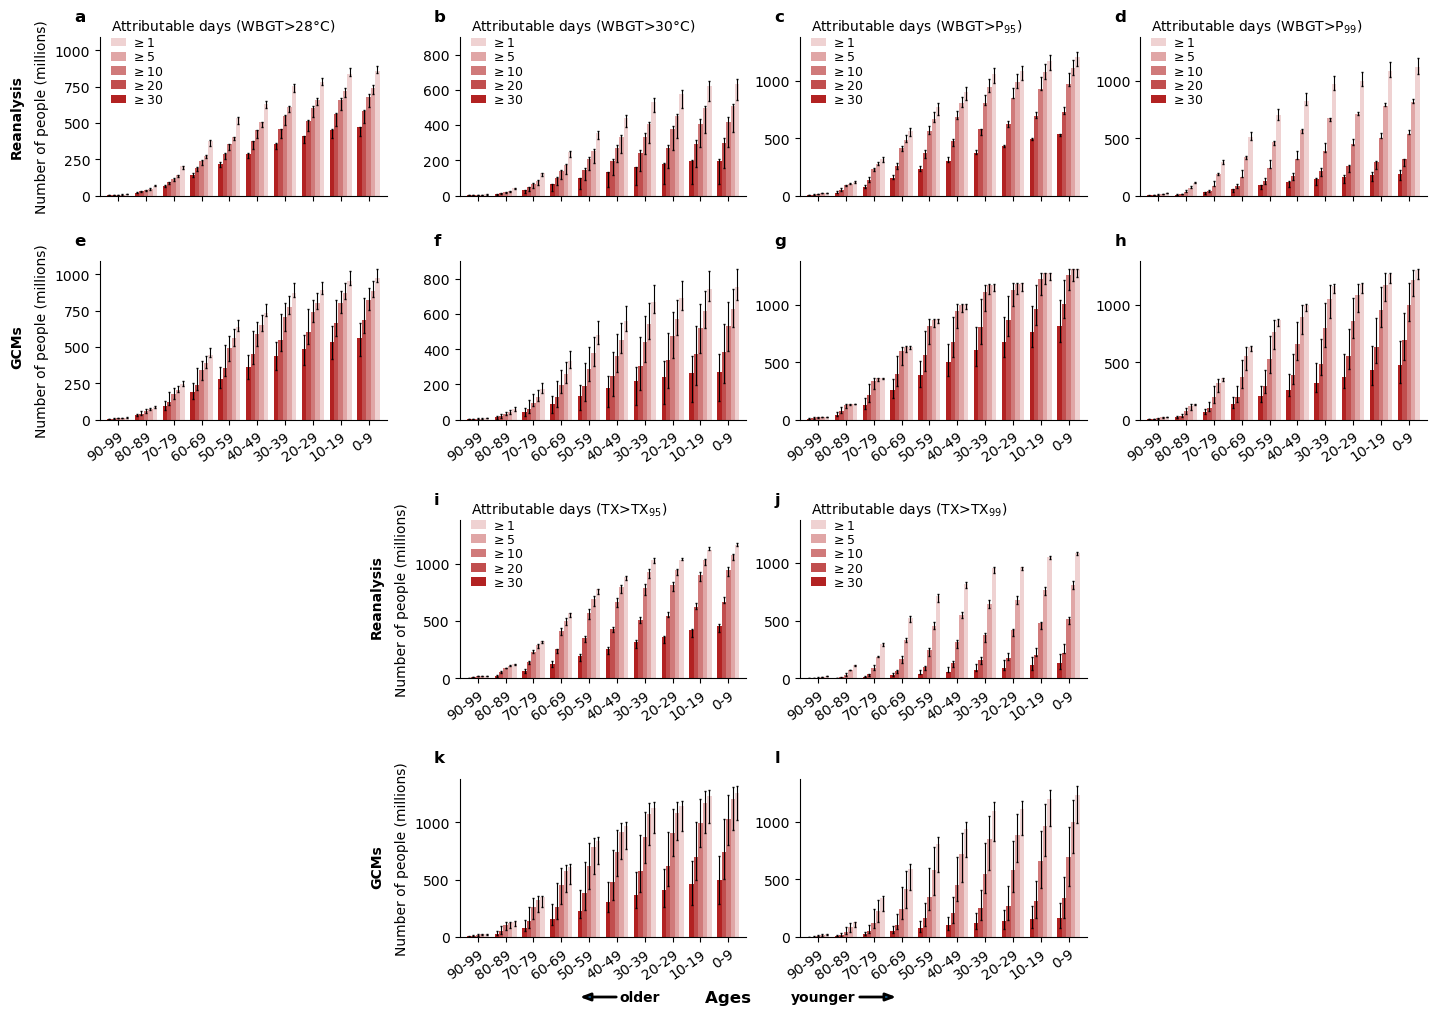

In [114]:
# settings
xpos=-.09
ypos=1.05

fig = plt.figure(figsize=(14, 10), layout='constrained', facecolor='none')  # layout constraint removed
gs = fig.add_gridspec(4, 4)  # Creating a grid with 2 rows and 4 columns

# Subplots
axes = []

# First row (Reanalysis)
axes.append(fig.add_subplot(gs[0, 0]))  # 'a'
axes.append(fig.add_subplot(gs[0, 1]))  # 'b'
axes.append(fig.add_subplot(gs[0, 2]))  # 'c'
axes.append(fig.add_subplot(gs[0, 3]))  # 'd'

# Second row (GCMs)
axes.append(fig.add_subplot(gs[1, 0]))  # 'e'
axes.append(fig.add_subplot(gs[1, 1]))  # 'f'
axes.append(fig.add_subplot(gs[1, 2]))  # 'g'
axes.append(fig.add_subplot(gs[1, 3]))  # 'h'

# Third row (Reanalysis)
axes.append(fig.add_subplot(gs[2, 1]))  # 'i'
axes.append(fig.add_subplot(gs[2, 2]))  # 'j'

# Fourth row (GCMs)
axes.append(fig.add_subplot(gs[3, 1]))  # 'k'
axes.append(fig.add_subplot(gs[3, 2]))  # 'l'


# Plotting
ax = axes[0]
ax.set_title('a', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_obs, unit=1e6, ax=ax, proportion=False, 
                                              legend=True, leg_title='Attributable days (WBGT>28$\degree$C)', 
                                              errcolor='k', color='firebrick', set_xticklabel=False, alpha_scale=True, width=.8)

ax = axes[1]
ax.set_title('b', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_obs_30, unit=1e6, ax=ax, proportion=False, 
                                              legend=True, leg_title='Attributable days (WBGT>30$\degree$C)', 
                                              errcolor='k', color='firebrick', set_xticklabel=False, alpha_scale=True, width=.8,ylabel='')

ax = axes[2]
ax.set_title('c', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_obs_W95, unit=1e6, ax=ax, proportion=False, 
                                              legend=True, leg_title='Attributable days (WBGT>P$_{95}$)', 
                                              errcolor='k', color='firebrick', set_xticklabel=False, alpha_scale=True, width=.8,ylabel='')

ax = axes[3]
ax.set_title('d', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_obs_W99, unit=1e6, ax=ax, proportion=False, 
                                              legend=True, leg_title='Attributable days (WBGT>P$_{99}$)', 
                                              errcolor='k', color='firebrick', set_xticklabel=False, alpha_scale=True, width=.8,ylabel='')

ax = axes[4]
ax.set_title('e', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_models, unit=1e6, ax=ax, proportion=False, 
                                              legend=False, errcolor='k', color='firebrick', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8)

ax = axes[5]
ax.set_title('f', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_models_30, unit=1e6, ax=ax, proportion=False, 
                                              legend=False, errcolor='k', color='firebrick', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8,ylabel='')

ax = axes[6]
ax.set_title('g', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_models_W95, unit=1e6, ax=ax, proportion=False, 
                                              legend=False, errcolor='k', color='firebrick', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8,ylabel='')

ax = axes[7]
ax.set_title('h', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_models_W99, unit=1e6, ax=ax, proportion=False, 
                                              legend=False, errcolor='k', color='firebrick', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8,ylabel='')


ax=axes[8]
ax.set_title('i',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_obs_TX95, unit=1e6, ax=ax, proportion=False, 
                                              legend=True, errcolor='k', color='firebrick', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8,leg_title='Attributable days (TX>TX$_{95}$)')

ax=axes[9]
ax.set_title('j',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_obs_TX99, unit=1e6, ax=ax, proportion=False, 
                                              legend=True, errcolor='k', color='firebrick', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8,ylabel='',leg_title='Attributable days (TX>TX$_{99}$)')




ax=axes[10]
ax.set_title('k',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_models_TX95, unit=1e6, ax=ax, proportion=False, 
                                              legend=False,errcolor='k',
                                              color='firebrick',set_xticklabel=True,rotation=35,
                                              alpha_scale=True,width=.8,
                                             )

ax=axes[11]
ax.set_title('l',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_median(da_n_people_ndays_models_TX99, unit=1e6,  ax=ax, proportion=False, 
                                              legend=False,errcolor='k',
                                              color='firebrick',set_xticklabel=True,rotation=35,
                                              alpha_scale=True,width=.8,ylabel=''
                                             )




# Scale y axes to match
[axes[i].set_ylim(axes[j].get_ylim()) for i,j in [(0,4),(1,5),(2,6),(3,7),(8,10),(9,11)]]

# Annotations 
fig.text(-.015, .85, 'Reanalysis', ha='left', rotation=90, fontweight='bold')
fig.text(-.015, .64, 'GCMs', ha='left', rotation=90, fontweight='bold')
fig.text(.242, .37, 'Reanalysis', ha='left', rotation=90, fontweight='bold')
fig.text(.242, .12, 'GCMs', ha='left', rotation=90, fontweight='bold')
fig.supxlabel('Ages ', y=0, fontweight='bold')

# Arrow annotation older/younger 
vloc=0.008
arr = mpatches.FancyArrowPatch((0.59, vloc), (0.62, vloc),  # Coordinates in figure fraction
                               arrowstyle='-|>,head_width=.15',  
                               mutation_scale=15,  
                               linewidth=2,  
                               transform=fig.transFigure,  
                               )
fig.patches.append(arr)
fig.text(0.543, 0.008, "younger", ha='left', va='center', fontweight='bold')
arr = mpatches.FancyArrowPatch((.42, vloc), (.39, vloc),  
                               arrowstyle='-|>,head_width=.15',  
                               mutation_scale=15,  
                               linewidth=2,  
                               transform=fig.transFigure,  
                               )  
fig.patches.append(arr)
fig.text(0.42, vloc, "older", ha='left', va='center', fontweight='bold')

for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Save the figure
#plt.savefig(os.path.join(figdir, 'figSI4_npeople.png'), dpi=300, bbox_inches='tight', transparent=True)
#plt.savefig(os.path.join(figdir, 'figSI4_npeople.pdf'), dpi=300, bbox_inches='tight', transparent=True)


## 2) Proportion of people

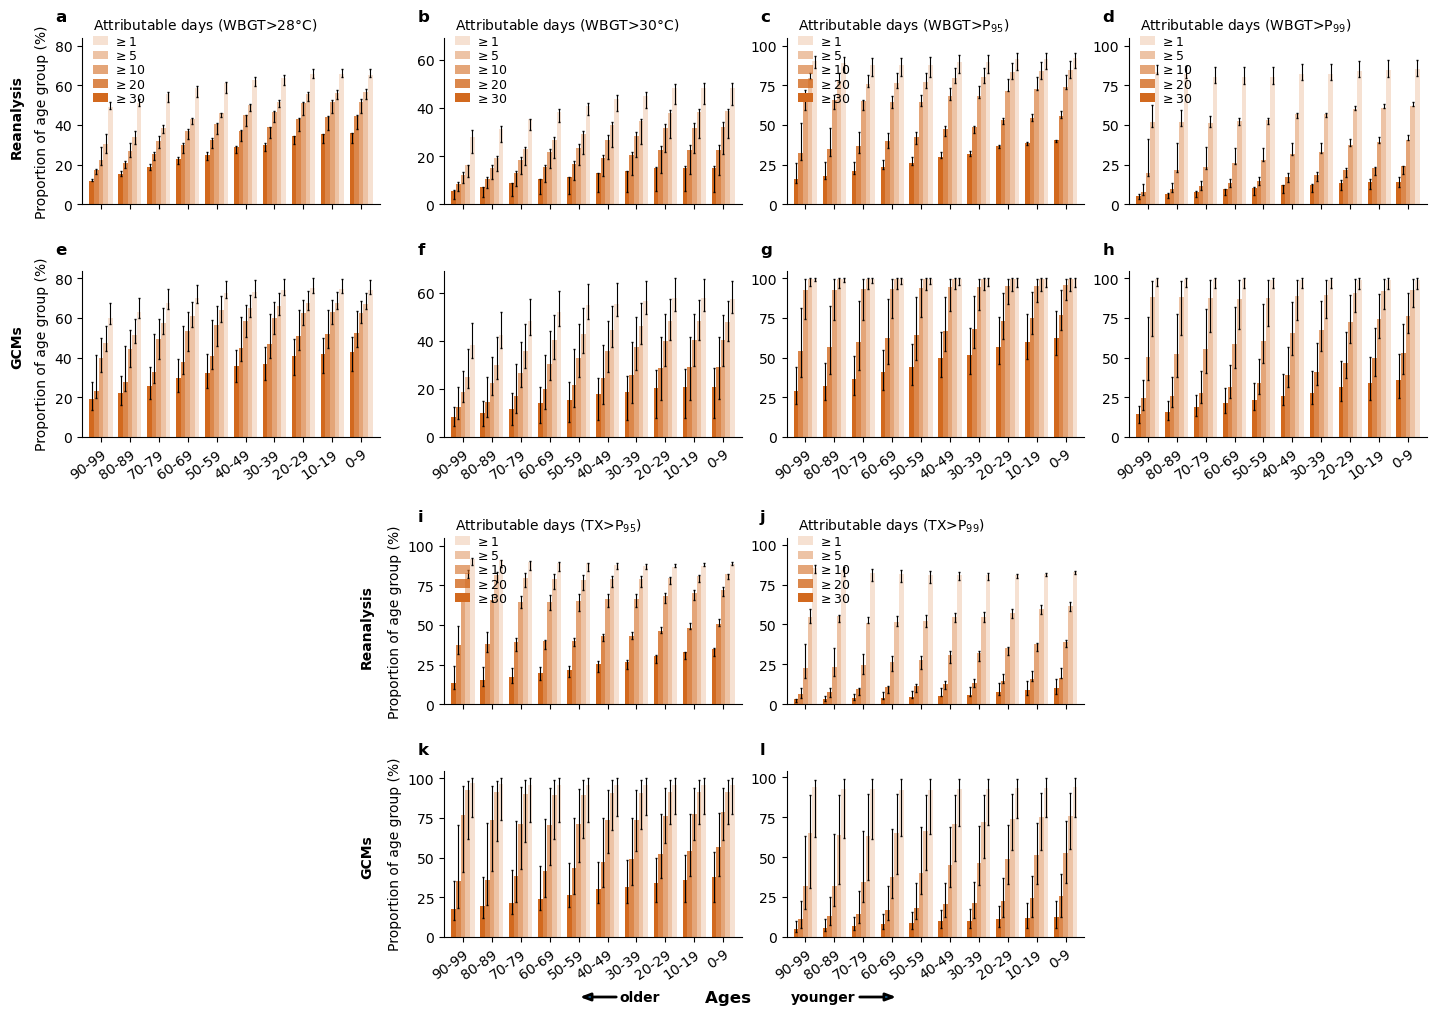

In [115]:
# settings
xpos=-.09
ypos=1.05

fig = plt.figure(figsize=(14, 10), layout='constrained', facecolor='none')  # layout constraint removed
gs = fig.add_gridspec(4, 4)  # Creating a grid with 2 rows and 4 columns

# Subplots
axes = []

# First row (Reanalysis)
axes.append(fig.add_subplot(gs[0, 0]))  # 'a'
axes.append(fig.add_subplot(gs[0, 1]))  # 'b'
axes.append(fig.add_subplot(gs[0, 2]))  # 'c'
axes.append(fig.add_subplot(gs[0, 3]))  # 'd'

# Second row (GCMs)
axes.append(fig.add_subplot(gs[1, 0]))  # 'e'
axes.append(fig.add_subplot(gs[1, 1]))  # 'f'
axes.append(fig.add_subplot(gs[1, 2]))  # 'g'
axes.append(fig.add_subplot(gs[1, 3]))  # 'h'

# Third row (Reanalysis)
axes.append(fig.add_subplot(gs[2, 1]))  # 'i'
axes.append(fig.add_subplot(gs[2, 2]))  # 'j'

# Fourth row (GCMs)
axes.append(fig.add_subplot(gs[3, 1]))  # 'k'
axes.append(fig.add_subplot(gs[3, 2]))  # 'l'


# Plotting
ax = axes[0]
ax.set_title('a', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_obs*100, unit=1, ax=ax, proportion=True, 
                                              legend=True, leg_title='Attributable days (WBGT>28$\degree$C)', 
                                              errcolor='k', color='chocolate', set_xticklabel=False, alpha_scale=True, width=.8)

ax = axes[1]
ax.set_title('b', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_obs_30*100, unit=1, ax=ax, proportion=True, 
                                              legend=True, leg_title='Attributable days (WBGT>30$\degree$C)', 
                                              errcolor='k', color='chocolate', set_xticklabel=False, alpha_scale=True, width=.8,ylabel='')

ax = axes[2]
ax.set_title('c', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_obs_W95*100, unit=1, ax=ax, proportion=True, 
                                              legend=True, leg_title='Attributable days (WBGT>P$_{95}$)', 
                                              errcolor='k', color='chocolate', set_xticklabel=False, alpha_scale=True, width=.8,ylabel='')

ax = axes[3]
ax.set_title('d', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_obs_W99*100, unit=1, ax=ax, proportion=True, 
                                              legend=True, leg_title='Attributable days (WBGT>P$_{99}$)', 
                                              errcolor='k', color='chocolate', set_xticklabel=False, alpha_scale=True, width=.8,ylabel='')

ax = axes[4]
ax.set_title('e', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_models*100, unit=1, ax=ax, proportion=True, 
                                              legend=False, errcolor='k', color='chocolate', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8)

ax = axes[5]
ax.set_title('f', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_models_30*100, unit=1, ax=ax, proportion=True, 
                                              legend=False, errcolor='k', color='chocolate', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8,ylabel='')

ax = axes[6]
ax.set_title('g', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_models_W95*100, unit=1, ax=ax, proportion=True, 
                                              legend=False, errcolor='k', color='chocolate', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8,ylabel='')

ax = axes[7]
ax.set_title('h', loc='left', fontweight='bold', x=xpos, y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_models_W99*100, unit=1, ax=ax, proportion=True, 
                                              legend=False, errcolor='k', color='chocolate', set_xticklabel=True, rotation=35, 
                                              alpha_scale=True, width=.8,ylabel='')


ax=axes[8]
ax.set_title('i',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_obs_TX95*100, unit=1, ax=ax, proportion=True, 
                                              legend=True, leg_title='Attributable days (TX>P$_{95}$)', 
                                              errcolor='k', color='chocolate', set_xticklabel=False, alpha_scale=True, width=.8,)

ax=axes[9]
ax.set_title('j',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_obs_TX99*100, unit=1, ax=ax, proportion=True, 
                                              legend=True, leg_title='Attributable days (TX>P$_{99}$)', 
                                              errcolor='k', color='chocolate', set_xticklabel=False, alpha_scale=True, width=.8,ylabel='')




ax=axes[10]
ax.set_title('k',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_models_TX95*100, unit=1, ax=ax, proportion=True, 
                                              legend=False,errcolor='k',
                                              color='chocolate',set_xticklabel=True,rotation=35,
                                              alpha_scale=True,width=.8,
                                             )

ax=axes[11]
ax.set_title('l',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_median(da_prop_people_ndays_models_TX99*100, unit=1,  ax=ax, proportion=True, 
                                              legend=False,errcolor='k',
                                              color='chocolate',set_xticklabel=True,rotation=35,
                                              alpha_scale=True,width=.8,ylabel=''
                                             )




# Scale y axes to match
[axes[i].set_ylim(axes[j].get_ylim()) for i,j in [(0,4),(1,5),(2,6),(3,7),(8,10),(9,11)]]


# Annotations 
fig.text(-.015, .85, 'Reanalysis', ha='left', rotation=90, fontweight='bold')
fig.text(-.015, .64, 'GCMs', ha='left', rotation=90, fontweight='bold')
fig.text(.235, .34, 'Reanalysis', ha='left', rotation=90, fontweight='bold')
fig.text(.235, .13, 'GCMs', ha='left', rotation=90, fontweight='bold')
fig.supxlabel('Ages ', y=0, fontweight='bold')

# Arrow annotation older/younger 
vloc=0.008
arr = mpatches.FancyArrowPatch((0.59, vloc), (0.62, vloc),  # Coordinates in figure fraction
                               arrowstyle='-|>,head_width=.15',  
                               mutation_scale=15,  
                               linewidth=2,  
                               transform=fig.transFigure,  
                               )
fig.patches.append(arr)
fig.text(0.543, 0.008, "younger", ha='left', va='center', fontweight='bold')
arr = mpatches.FancyArrowPatch((.42, vloc), (.39, vloc),  
                               arrowstyle='-|>,head_width=.15',  
                               mutation_scale=15,  
                               linewidth=2,  
                               transform=fig.transFigure,  
                               )  
fig.patches.append(arr)
fig.text(0.42, vloc, "older", ha='left', va='center', fontweight='bold')

# flip xaxis and remove spines
for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Save the figure
#plt.savefig(os.path.join(figdir, 'figSI5_proppeople.png'), dpi=300, bbox_inches='tight', transparent=True)
#plt.savefig(os.path.join(figdir, 'figSI5_proppeople.pdf'), dpi=300, bbox_inches='tight', transparent=True)


## Summary results

In [116]:
da_n_people_ndays_models_TX99.mean(dim='model').to_pandas().applymap(format_large_numbers)

features,n_atleast_1,n_atleast_5,n_atleast_10,n_atleast_20,n_atleast_30
age_ranges,,,,,
0,0B,980M,700M,360M,190M
10,0B,940M,660M,330M,180M
20,0B,860M,590M,290M,160M
30,0B,830M,540M,260M,140M
40,910M,700M,450M,220M,120M
50,780M,590M,370M,170M,90M
60,570M,420M,260M,110M,60M
70,330M,240M,140M,60M,30M
80,120M,90M,50M,20M,10M


In [117]:
(da_prop_people_ndays_models_TX99*100).mean(dim='model').to_pandas().round(2)

features,prop_atleast_1,prop_atleast_5,prop_atleast_10,prop_atleast_20,prop_atleast_30
age_ranges,,,,,
0,91.20,74.68,53.05,27.37,14.32
10,90.80,73.47,51.26,26.04,13.73
20,90.46,72.27,49.37,24.64,13.11
30,90.06,70.04,46.15,22.37,11.77
40,90.09,69.49,45.15,21.61,11.49
50,89.65,67.07,41.81,19.24,10.11
60,89.85,66.36,39.98,17.64,9.15
70,90.12,65.21,37.69,15.54,7.85
80,90.85,64.75,35.76,13.53,6.77


## 3) Suppl figure: part 2 days per cap

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

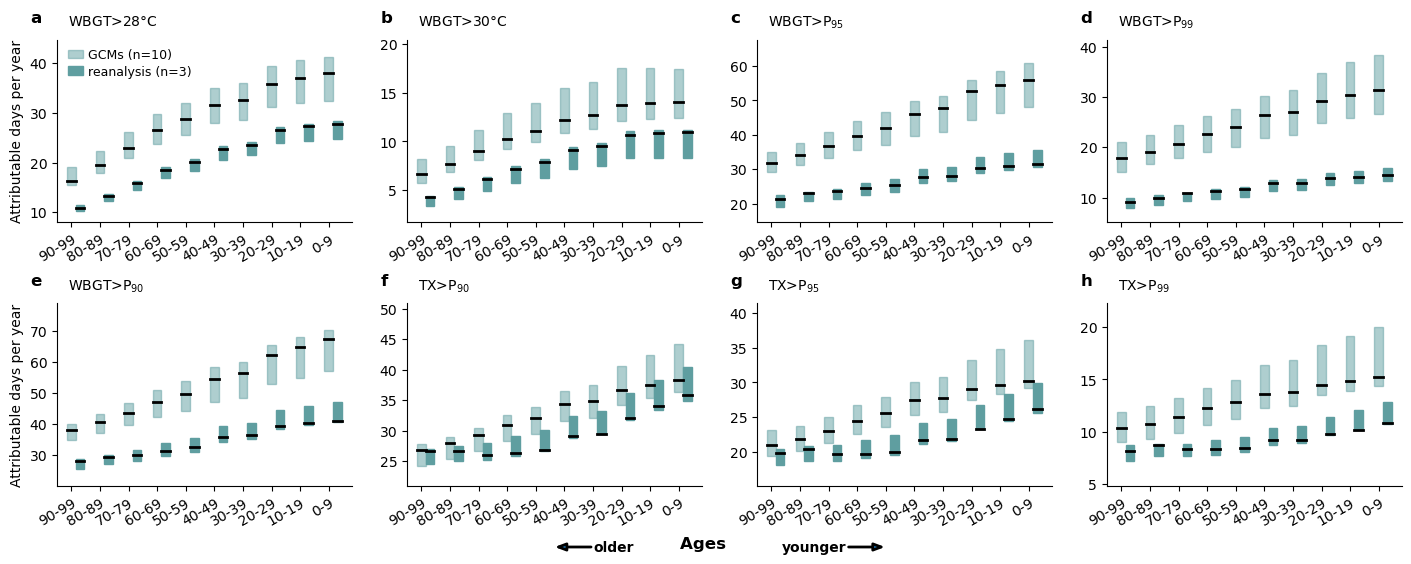

In [118]:
# settings
xpos=-.09
ypos=1.05
shift = 0.15

#ylab=

fig,axes=plt.subplots(2,4,figsize=(14,5.5),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()


ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=False,
                              set_xticks=False,
                             rotation=30,
                             #ylabel='Average attributable days per year',
                              legend=True, 
                              leg_title='WBGT>28$\degree$C',
                              positions = [x - shift for x in range(1,11)],
                              widths=.3
                             )

plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_models,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=True,
                             rotation=30,
                             ylabel='Attributable days per year',
                              legend=False, 
                              positions = [x + shift for x in range(1,11)],
                              alpha=.5,
                              widths=.3
                             )




ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_30,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=False,
                              set_xticks=False,
                             rotation=30,
                            # ylabel='Attributable days per year',
                              legend=True, 
                              leg_title='WBGT>30$\degree$C',
                              positions = [x - shift for x in range(1,11)],
                              widths=.3
                             )

plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_models_30,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=True,
                             rotation=30,
                             ylabel='',
                              legend=False, 
                              positions = [x + shift for x in range(1,11)],
                              alpha=.5,
                              widths=.3
                             )



ax=axes[2]
#ax.set_ylim(axes[0].get_ylim())
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_W95,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=False,
                              set_xticks=False,
                             rotation=30,
                            # ylabel='Attributable days per year',
                              legend=True, 
                              leg_title='WBGT>P$_{95}$',
                              positions = [x - shift for x in range(1,11)],
                              widths=.3
                             )

plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_models_W95,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=True,
                             rotation=30,
                             ylabel='',
                              legend=False, 
                              positions = [x + shift for x in range(1,11)],
                              alpha=.5,
                              widths=.3
                             )




ax=axes[3]
ax.set_title('d',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_W99,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=False,
                              set_xticks=False,
                             rotation=30,
                           #  ylabel='Attributable days per year',
                              legend=True, 
                              leg_title='WBGT>P$_{99}$',
                              positions = [x - shift for x in range(1,11)],
                              widths=.3
                             )

plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_models_W99,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=True,
                             rotation=30,
                             ylabel='',
                              legend=False, 
                              positions = [x + shift for x in range(1,11)],
                              alpha=.5,
                              widths=.3
                             )


ax=axes[4]
ax.set_title('e',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_W90,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=False,
                              set_xticks=False,
                             rotation=30,
                              legend=True, 
                              leg_title='WBGT>P$_{90}$',
                              positions = [x - shift for x in range(1,11)],
                              widths=.3
                             )

plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_models_W90,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=True,
                             rotation=30,
                              ylabel='Attributable days per year',                              
                              legend=False, 
                              positions = [x + shift for x in range(1,11)],
                              alpha=.5,
                              widths=.3
                             )



ax=axes[5]
ax.set_title('f',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_TX90,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=False,
                              set_xticks=False,
                             rotation=30,
                           #  ylabel='Attributable days per year',
                              legend=True, 
                              #leg_title='WBGT>P$_{90}$',
                              positions = [x - shift for x in range(1,11)],
                              widths=.3
                             )
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_models_TX90,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=True,
                             rotation=30,
                             ylabel=' ',
                              legend=True, 
                              leg_title='TX>P$_{90}$',
                              positions = [x + shift for x in range(1,11)],
                              alpha=.5,
                              widths=.3
                             )



ax=axes[6]
ax.set_title('g',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_TX95,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=False,
                              set_xticks=False,
                             rotation=30,
                           #  ylabel='Attributable days per year',
                              legend=True, 
                              #leg_title='WBGT>P$_{90}$',
                              positions = [x - shift for x in range(1,11)],
                              widths=.3
                             )
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_models_TX95,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=True,
                             rotation=30,
                             ylabel=' ',
                              legend=True, 
                              leg_title='TX>P$_{95}$',
                              positions = [x + shift for x in range(1,11)],
                              alpha=.5,
                              widths=.3
                             )





ax=axes[7]
ax.set_title('h',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_TX99,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=False,
                              set_xticks=False,
                             rotation=30,
                           #  ylabel='Attributable days per year',
                              legend=True, 
                              #leg_title='WBGT>P$_{90}$',
                              positions = [x - shift for x in range(1,11)],
                              widths=.3
                             )
plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_models_TX99,
                              feature='per_capita_days',
                              ax=ax,
                             set_xticklabel=True,
                             rotation=30,
                             ylabel=' ',
                              legend=True, 
                              leg_title='TX>P$_{99}$',
                              positions = [x + shift for x in range(1,11)],
                              alpha=.5,
                              widths=.3
                             )





# not really using this loop - clean up 
titles = ['WBGT>28$\degree$C',
          'WBGT>30$\degree$C',
          'WBGT>P$_{95}$',
          'WBGT>P$_{99}$'

]

for ax in [axes[0]]:
    mod_patch = mpatches.Patch(color='cadetblue', alpha=0.5, label='GCMs (n=10)')
    obs_patch = mpatches.Patch(color='cadetblue', label='reanalysis (n=3)')
    leg = ax.legend(handles = [mod_patch, obs_patch ], fontsize=9,frameon=False, loc='upper left',
              handlelength=1.2,handletextpad=0.4,labelspacing = .3,
                    bbox_to_anchor=(0, 1.2),
             title=titles[0]+'\n') 
    leg._legend_box.align = "left"




# Annotations 
fig.supxlabel('Ages ', fontweight='bold'); 




# arrow annotation older/younger 
arr = mpatches.FancyArrowPatch((0.6, 0.015), (0.63, 0.015),  # Coordinates in figure fraction
                               arrowstyle='-|>,head_width=.15',  
                               mutation_scale=15,  
                               linewidth=2,  
                               transform=fig.transFigure,  
                               )
fig.patches.append(arr)
fig.text(0.554, 0.015, "younger", ha='left', va='center', fontweight='bold')
arr = mpatches.FancyArrowPatch((.42, 0.015), (.39, 0.015),  
                               arrowstyle='-|>,head_width=.15',  
                               mutation_scale=15,  
                               linewidth=2,  
                               transform=fig.transFigure,  
                               )  
fig.patches.append(arr)
fig.text(0.42, 0.015, "older", ha='left', va='center',fontweight='bold')

for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# Try as dots instead of IQR bar??

#plt.savefig(os.path.join(figdir,'figSI6_percap.png'),dpi=300,bbox_inches='tight',transparent=True)
#plt.savefig(os.path.join(figdir,'figSI6_percap.pdf'),dpi=300,bbox_inches='tight',transparent=True)

# Summary results

## 1. n/prop people exposed to n attributable days (comms)

In [ ]:
da_n_people_ndays_obs.astype(float).median(dim='model').to_pandas().applymap(format_large_numbers) 

# 28 degrees - reanalysis

features,n_atleast_1,n_atleast_5,n_atleast_10,n_atleast_20,n_atleast_30
age_ranges,,,,,
0,860M,740M,680M,580M,470M
10,840M,720M,660M,560M,450M
20,780M,660M,600M,510M,410M
30,750M,610M,550M,460M,350M
40,630M,510M,450M,370M,290M
50,540M,400M,350M,280M,220M
60,370M,270M,240M,190M,140M
70,200M,140M,120M,90M,70M
80,70M,50M,40M,30M,20M


In [14]:
da_n_people_ndays_models.astype(float).median(dim='model').to_pandas().applymap(format_large_numbers)

# GCMs

features,n_atleast_1,n_atleast_5,n_atleast_10,n_atleast_20,n_atleast_30
age_ranges,,,,,
0,970M,880M,820M,690M,560M
10,960M,870M,810M,660M,540M
20,890M,800M,740M,610M,490M
30,870M,780M,710M,550M,440M
40,740M,650M,590M,450M,360M
50,640M,560M,490M,360M,280M
60,450M,390M,340M,240M,190M
70,240M,210M,180M,120M,90M
80,80M,70M,60M,40M,30M


In [15]:
df = da_n_people_ndays_models.astype(float).median(dim='model').to_pandas()
(df.loc[0] / df.loc[60]).round(0)

# ratio n people aged 0-9 vs. 60-69 experiencing that many days (GCMs)

features
n_atleast_1     2.0
n_atleast_5     2.0
n_atleast_10    2.0
n_atleast_20    3.0
n_atleast_30    3.0
dtype: float64

In [21]:
(da_prop_people_ndays_models*100).astype(float).median(dim='model').to_pandas().applymap(format_large_numbers) 

features,prop_atleast_1,prop_atleast_5,prop_atleast_10,prop_atleast_20,prop_atleast_30
age_ranges,,,,,
0,74,67,63,52,43
10,75,68,63,52,42
20,75,68,62,51,41
30,74,66,60,47,37
40,73,65,58,45,36
50,73,64,56,41,32
60,70,61,53,38,30
70,67,57,49,33,26
80,63,52,44,28,22


In [122]:
da_n_people_ndays_obs_30.mean(dim='model').to_pandas().applymap(format_large_numbers)

features,n_atleast_1,n_atleast_5,n_atleast_10,n_atleast_20,n_atleast_30
age_ranges,,,,,
0,610M,460M,380M,260M,160M
10,600M,450M,370M,260M,160M
20,560M,420M,340M,240M,140M
30,520M,380M,310M,210M,130M
40,430M,310M,250M,170M,100M
50,350M,230M,190M,130M,80M
60,240M,160M,130M,90M,50M
70,120M,80M,60M,40M,30M
80,40M,20M,20M,10M,10M


In [123]:
(da_prop_people_ndays_obs_30*100).mean(dim='model').to_pandas().applymap(format_large_numbers) 

features,prop_atleast_1,prop_atleast_5,prop_atleast_10,prop_atleast_20,prop_atleast_30
age_ranges,,,,,
0,47,35,29,20,12
10,47,35,29,20,12
20,47,35,29,20,12
30,44,32,26,18,11
40,43,30,25,17,10
50,40,27,22,15,9
60,37,25,20,14,8
70,34,21,17,12,7
80,30,18,14,10,6


# Supplementary figure: total vs. attributable heat stress

### reanalysis

In [18]:
# calc p1
days_in_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
days_in_month_da = xr.DataArray(days_in_month, dims=['month'], coords={'month': da_p1['month']})
da_p1_obs = (da_p1 * days_in_month_da).sum(dim='month')
da_p0_obs = (da_p0 * days_in_month_da).sum(dim='month')

In [19]:
# reanalysis 


# people x days

people_x_nAHD_obs = (da_nAHD_obs * gs_population_global).squeeze()
people_x_nAHD_obs

people_x_totaldays_obs = (da_p1_obs * gs_population_global).squeeze()
people_x_totaldays_obs

<xarray.DataArray (dataset: 3, lat: 360, lon: 720, ages: 105)>
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]])
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * dataset  (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'
    time     int64 2023
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

In [20]:
da_totaldays_percapita_peopledays_10y_obs = calc_percapita_hotdays_peopledays_1yr(gs_population_global, 
                                                                           datasets, 
                                                                           da_p1_obs.rename({'dataset':'model'}),
                                                                           x_hot_days = [1,5,10,20,30], 
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

In [21]:
da_nAHD_percapita_peopledays_10y_obs

<xarray.DataArray (model: 3, age_ranges: 10, features: 2)>
array([[[3.77739129e+10, 2.87313723e+01],
        [3.63586902e+10, 2.83307098e+01],
        [3.29798517e+10, 2.77224889e+01],
        [2.93367644e+10, 2.48675276e+01],
        [2.42790378e+10, 2.41124047e+01],
        [1.86971049e+10, 2.13620891e+01],
        [1.25597373e+10, 1.96822179e+01],
        [6.10182926e+09, 1.69023506e+01],
        [1.93419343e+09, 1.43078281e+01],
        [2.87495100e+08, 1.19910544e+01]],

       [[2.85700285e+10, 2.17307676e+01],
        [2.76165893e+10, 2.15188603e+01],
        [2.52368860e+10, 2.12138399e+01],
        [2.27112468e+10, 1.92513581e+01],
        [1.86490974e+10, 1.85211040e+01],
        [1.45859347e+10, 1.66649349e+01],
        [9.82053488e+09, 1.53896457e+01],
        [4.77751650e+09, 1.32339427e+01],
        [1.52071515e+09, 1.12492012e+01],
        [2.31097539e+08, 9.63878396e+00]],

       [[3.66312919e+10, 2.78622785e+01],
        [3.50547744e+10, 2.73146979e+01],
        [3.15585677e+10, 2.65277738e+01],
        [2.78996189e+10, 2.36493205e+01],
        [2.28911616e+10, 2.27340538e+01],
        [1.76194825e+10, 2.01308683e+01],
        [1.18433623e+10, 1.85595950e+01],
        [5.72863703e+09, 1.58685908e+01],
        [1.78750668e+09, 1.32227408e+01],
        [2.58756341e+08, 1.07923974e+01]]])
Coordinates:
  * age_ranges  (age_ranges) int64 0 10 20 30 40 50 60 70 80 90
  * features    (features) object 'people_days' 'per_capita_days'
  * model       (model) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'

### Figures

<Axes: xlabel='age_ranges'>

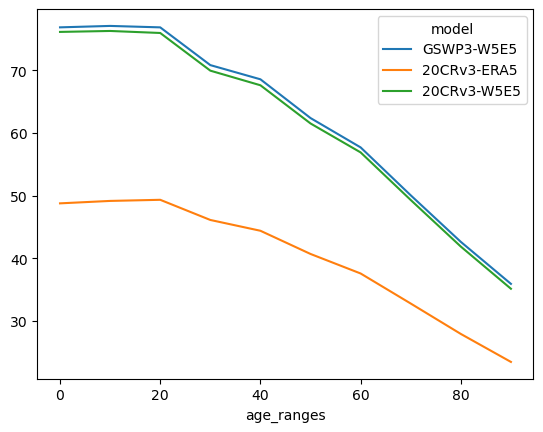

In [22]:
da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T.plot()

<Axes: xlabel='age_ranges'>

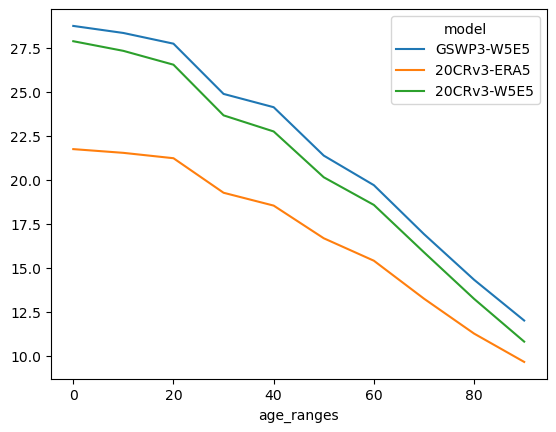

In [129]:
da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T.plot()

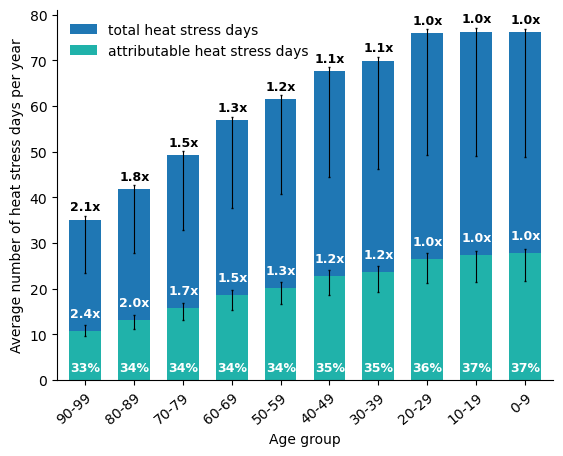

In [130]:
fig, ax = plt.subplots()

plot_barplot_n_prop_people_atleastx_median(da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days'), 
                                                  unit=1, 
                                                  ax=ax, 
                                                  proportion=False, 
                                                  x_hot_days = None,
                                                 legend=False,
                                                 errcolor='k',
                                                 color='C0',
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel='Number of days per year',
                                                 alpha_scale=False,
                                                 width=.65,
                                                 leg_title=None)

plot_barplot_n_prop_people_atleastx_median(da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days'), 
                                                  unit=1, 
                                                  ax=ax, 
                                                  proportion=False, 
                                                  x_hot_days = None,
                                                 legend=False,
                                                 errcolor='k',
                                                 color='lightseagreen',
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel='Average number of heat stress days per year',
                                                 alpha_scale=False,
                                                 width=.65,
                                                 leg_title=None)


# annotate with multiplication factors

# total days 
df = da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
for i in range(10):
    val = df.agg(['median'],axis=1).iloc[i].values
    EMF = (df.iloc[0,:] / df).agg(['median'],axis=1).round(1).iloc[i].values[0]
    ax.annotate(f'{EMF}x', (i+.3, val+2), fontweight='bold', c='k', fontsize=9)

# attr days 
df = da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
for i in range(10):
    val = df.agg(['median'],axis=1).iloc[i].values
    EMF = (df.iloc[0,:] / df).agg(['median'],axis=1).round(1).iloc[i].values[0]
    ax.annotate(f'{EMF}x', (i+.3, val+3), fontweight='bold',  c='white', fontsize=9 )


# what % of the total is attributable per age group, write underneath 
df1 = da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
df2 = da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
for i in range(10):
    percent = (df2/df1).agg(['median'],axis=1).round(2).iloc[i].values[0]
    ax.annotate(f'{int(percent*100)}%', (i+.3, 2), fontweight='bold',  c='white', fontsize=9 )




# labels

ax.legend(labels = ['total heat stress days', 'attributable heat stress days'], frameon=False)
ax.set_xlabel('Age group')
ax.invert_xaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [131]:
df = da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T

(df.iloc[0,:] / df).agg(['median', 'min', 'max'],axis=1).round(2)

,median,min,max
age_ranges,,,
0,1.00,1.00,1.00
10,1.00,0.99,1.00
20,1.00,0.99,1.00
30,1.09,1.06,1.09
40,1.12,1.10,1.13
50,1.23,1.20,1.24
60,1.33,1.30,1.34
70,1.54,1.49,1.54
80,1.80,1.75,1.82


In [132]:
df = da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T

(df.iloc[0,:] / df).agg(['median', 'min', 'max'],axis=1).round(2)

,median,min,max
age_ranges,,,
0,1.00,1.00,1.00
10,1.01,1.01,1.02
20,1.04,1.02,1.05
30,1.16,1.13,1.18
40,1.19,1.17,1.23
50,1.34,1.30,1.38
60,1.46,1.41,1.50
70,1.70,1.64,1.76
80,2.01,1.93,2.11


In [133]:
df1 = da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
df2 = da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
percent = (df2/df1).agg(['median','min', 'max'],axis=1).round(2)

percent

,median,min,max
age_ranges,,,
0,0.37,0.37,0.45
10,0.37,0.36,0.44
20,0.36,0.35,0.43
30,0.35,0.34,0.42
40,0.35,0.34,0.42
50,0.34,0.33,0.41
60,0.34,0.33,0.41
70,0.34,0.32,0.40
80,0.34,0.32,0.40


### AR6 regions

In [23]:
# per IPCC region average extra days? and % young people? 

import regionmask

# AR6 land regions
ar6 = regionmask.defined_regions.ar6.land
mask = ar6.mask(people_x_totaldays_obs)


pop_x_daystot_ar6_sum = (
    people_x_totaldays_obs.sum(dim='ages')
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
)

pop_x_nAHD_ar6_sum = (
        people_x_nAHD_obs.sum(dim='ages')
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])


)

pop_ar6_sum = (
    gs_population_global.sum(dim='ages')
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
)

totdays_per_person = (pop_x_daystot_ar6_sum / pop_ar6_sum).rename({"mask": "region"}).assign_coords(
    region=("region", ar6.names)
)

nAHD_per_person = (pop_x_nAHD_ar6_sum / pop_ar6_sum).rename({"mask": "region"}).assign_coords(
    region=("region", ar6.names)
)

#### Figurs

In [24]:
bins = np.arange(0, 111, 10) 

da = people_x_totaldays_obs.groupby_bins("ages", bins).sum()

pop_x_diff_ar6_010_sum = (
    da 
    .isel(ages_bins=0)
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
).rename({"mask": "region"}).squeeze().assign_coords(
    region=("region", ar6.names)).median('dataset')

pop_x_diff_ar6_1020_sum = (
    da 
    .isel(ages_bins=1)
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
).rename({"mask": "region"}).squeeze().assign_coords(
    region=("region", ar6.names)).median('dataset')

pop_x_diff_ar6_2030_sum = (
    da 
    .isel(ages_bins=2)
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
).rename({"mask": "region"}).squeeze().assign_coords(
    region=("region", ar6.names)).median('dataset')

pop_x_diff_ar6_3040_sum = (
    da 
    .isel(ages_bins=3)
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
).rename({"mask": "region"}).squeeze().assign_coords(
    region=("region", ar6.names)).median('dataset')

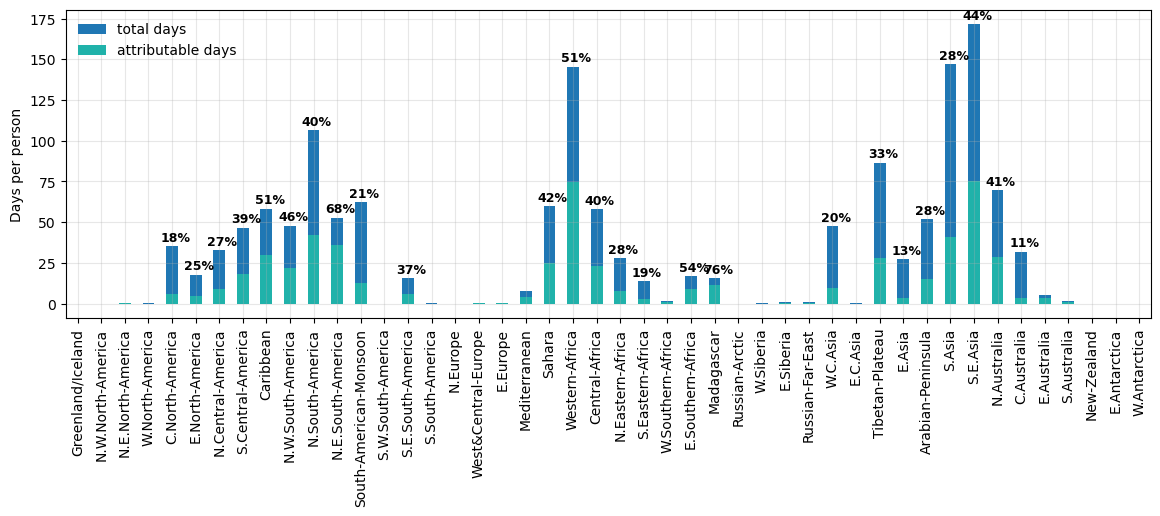

In [136]:
fig,ax=plt.subplots(figsize=(14,4))

totdays_per_person.median('dataset').squeeze().to_pandas().T.plot(kind="bar", ax=ax, label='total days')
nAHD_per_person.median('dataset').squeeze().to_pandas().T.plot(kind="bar", ax=ax, color='lightseagreen', label='attributable days')


# annotate
for i in range(46):
    tot = totdays_per_person.median('dataset').squeeze().to_pandas().T.iloc[i]
    percent = (nAHD_per_person.median('dataset').squeeze().to_pandas().T / totdays_per_person.median('dataset').squeeze().to_pandas().T).round(2).iloc[i] * 100
    if tot > 10 :
        ax.annotate(f'{int(percent)}%', (i-.5, tot+3), fontweight='bold',  c='k', fontsize=9 )

plt.ylabel('Days per person')
plt.xlabel('')
plt.grid(alpha=.3)
plt.legend(frameon=False)

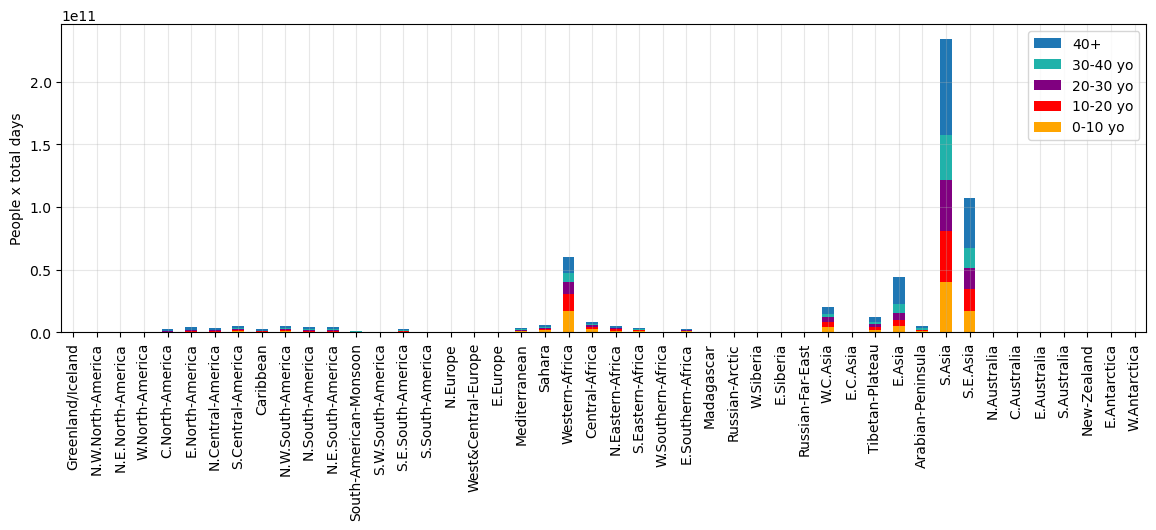

In [137]:
fig, ax = plt.subplots( figsize=(14,4))

pop_x_daystot_ar6_sum.median('dataset').squeeze().rename({"mask": "region"}).assign_coords(
    region=("region", ar6.names)
).to_pandas().plot(kind="bar",ax=ax, label='40+')


(pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum + pop_x_diff_ar6_2030_sum + pop_x_diff_ar6_3040_sum).to_pandas().plot(kind="bar", ax=ax, color='lightseagreen', label='30-40 yo')


(pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum + pop_x_diff_ar6_2030_sum).to_pandas().plot(kind="bar", ax=ax, color='purple', label='20-30 yo')


(pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum).to_pandas().plot(kind="bar", ax=ax, color='red', label='10-20 yo')

pop_x_diff_ar6_010_sum.to_pandas().plot(kind="bar", ax=ax, color='orange', label='0-10 yo')

plt.ylabel('People x total days')
plt.xlabel('')
plt.grid(alpha=.3)
plt.legend()



# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSImodeleval_nAHD_models_vs_reanalysis_difference_people_x_days_perregion.png'),dpi=300)

In [138]:
bins = np.arange(0, 111, 10) 

da = people_x_nAHD_obs.groupby_bins("ages", bins).sum()

pop_x_diff_ar6_010_sum2 = (
    da 
    .isel(ages_bins=0)
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
).rename({"mask": "region"}).squeeze().assign_coords(
    region=("region", ar6.names)).median('dataset')

pop_x_diff_ar6_1020_sum2 = (
    da 
    .isel(ages_bins=1)
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
).rename({"mask": "region"}).squeeze().assign_coords(
    region=("region", ar6.names)).median('dataset')

pop_x_diff_ar6_2030_sum2 = (
    da 
    .isel(ages_bins=2)
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
).rename({"mask": "region"}).squeeze().assign_coords(
    region=("region", ar6.names)).median('dataset')

pop_x_diff_ar6_3040_sum2 = (
    da 
    .isel(ages_bins=3)
    .groupby(mask)
    .sum(dim=["stacked_lat_lon"])
).rename({"mask": "region"}).squeeze().assign_coords(
    region=("region", ar6.names)).median('dataset')

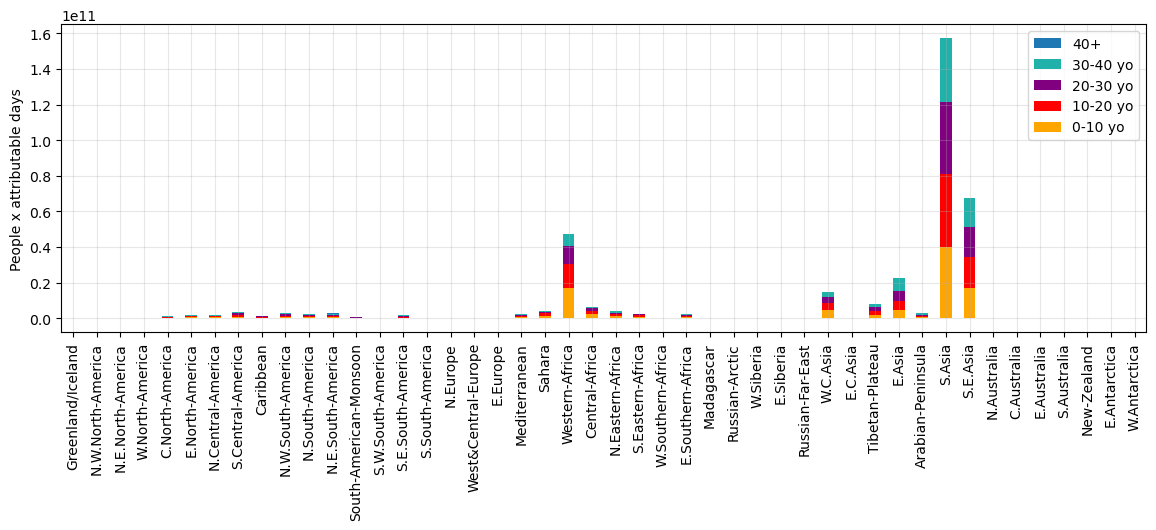

In [139]:
fig, ax = plt.subplots( figsize=(14,4))

pop_x_nAHD_ar6_sum.median('dataset').squeeze().rename({"mask": "region"}).assign_coords(
    region=("region", ar6.names)
).to_pandas().plot(kind="bar",ax=ax, label='40+')


(pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum + pop_x_diff_ar6_2030_sum + pop_x_diff_ar6_3040_sum).to_pandas().plot(kind="bar", ax=ax, color='lightseagreen', label='30-40 yo')


(pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum + pop_x_diff_ar6_2030_sum).to_pandas().plot(kind="bar", ax=ax, color='purple', label='20-30 yo')


(pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum).to_pandas().plot(kind="bar", ax=ax, color='red', label='10-20 yo')

pop_x_diff_ar6_010_sum.to_pandas().plot(kind="bar", ax=ax, color='orange', label='0-10 yo')

plt.ylabel('People x attributable days')
plt.xlabel('')
plt.grid(alpha=.3)
plt.legend()



# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSImodeleval_nAHD_models_vs_reanalysis_difference_people_x_days_perregion.png'),dpi=300)

(0.0, 100000000000.0)

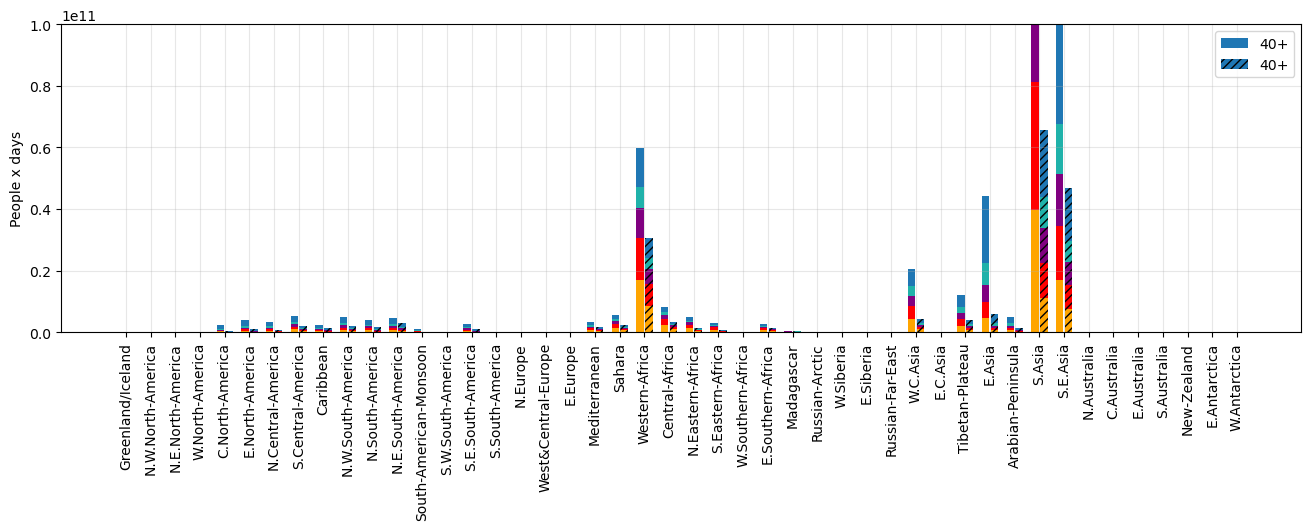

In [140]:
import numpy as np

base_series = pop_x_diff_ar6_010_sum.to_pandas()
regions = base_series.index



fig, ax = plt.subplots( figsize=(16,4))

x = np.arange(len(regions))
width = 0.3   # narrow bars
offset = 0.18  # shift amount for second cluster


series_40plus = pop_x_daystot_ar6_sum.median('dataset').squeeze().rename({"mask": "region"}).assign_coords(
    region=("region", ar6.names)
).to_pandas()

ax.bar(x - offset , series_40plus, width, label='40+', color='C0')
ax.bar(x- offset , (pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum + pop_x_diff_ar6_2030_sum + pop_x_diff_ar6_3040_sum).to_pandas(), width, color='lightseagreen')
ax.bar(x- offset, (pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum + pop_x_diff_ar6_2030_sum).to_pandas(), width, color='purple')
ax.bar(x- offset , (pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum).to_pandas(), width, color='red')
ax.bar(x- offset , pop_x_diff_ar6_010_sum.to_pandas(), width, color='orange')

series_40plus = pop_x_nAHD_ar6_sum.median('dataset').squeeze().rename({"mask": "region"}).assign_coords(
    region=("region", ar6.names)
).to_pandas()


ax.bar(x + offset , series_40plus, width, label='40+', color='C0', hatch='////')
ax.bar(x + offset, (pop_x_diff_ar6_010_sum2 + pop_x_diff_ar6_1020_sum2 + pop_x_diff_ar6_2030_sum2 + pop_x_diff_ar6_3040_sum2).to_pandas(), width, color='lightseagreen', hatch='////')
ax.bar(x + offset, (pop_x_diff_ar6_010_sum2 + pop_x_diff_ar6_1020_sum2 + pop_x_diff_ar6_2030_sum2).to_pandas(), width, color='purple', hatch='////')
ax.bar(x + offset, (pop_x_diff_ar6_010_sum2 + pop_x_diff_ar6_1020_sum2).to_pandas(), width, color='red', hatch='////')
ax.bar(x + offset, pop_x_diff_ar6_010_sum2.to_pandas(), width, color='orange', hatch='////')









ax.set_xticks(x )
ax.set_xticklabels(regions, rotation=90)

plt.ylabel('People x days')
plt.xlabel('')
plt.grid(alpha=.3)
plt.legend()

plt.ylim(0,1e11)


## Subplots

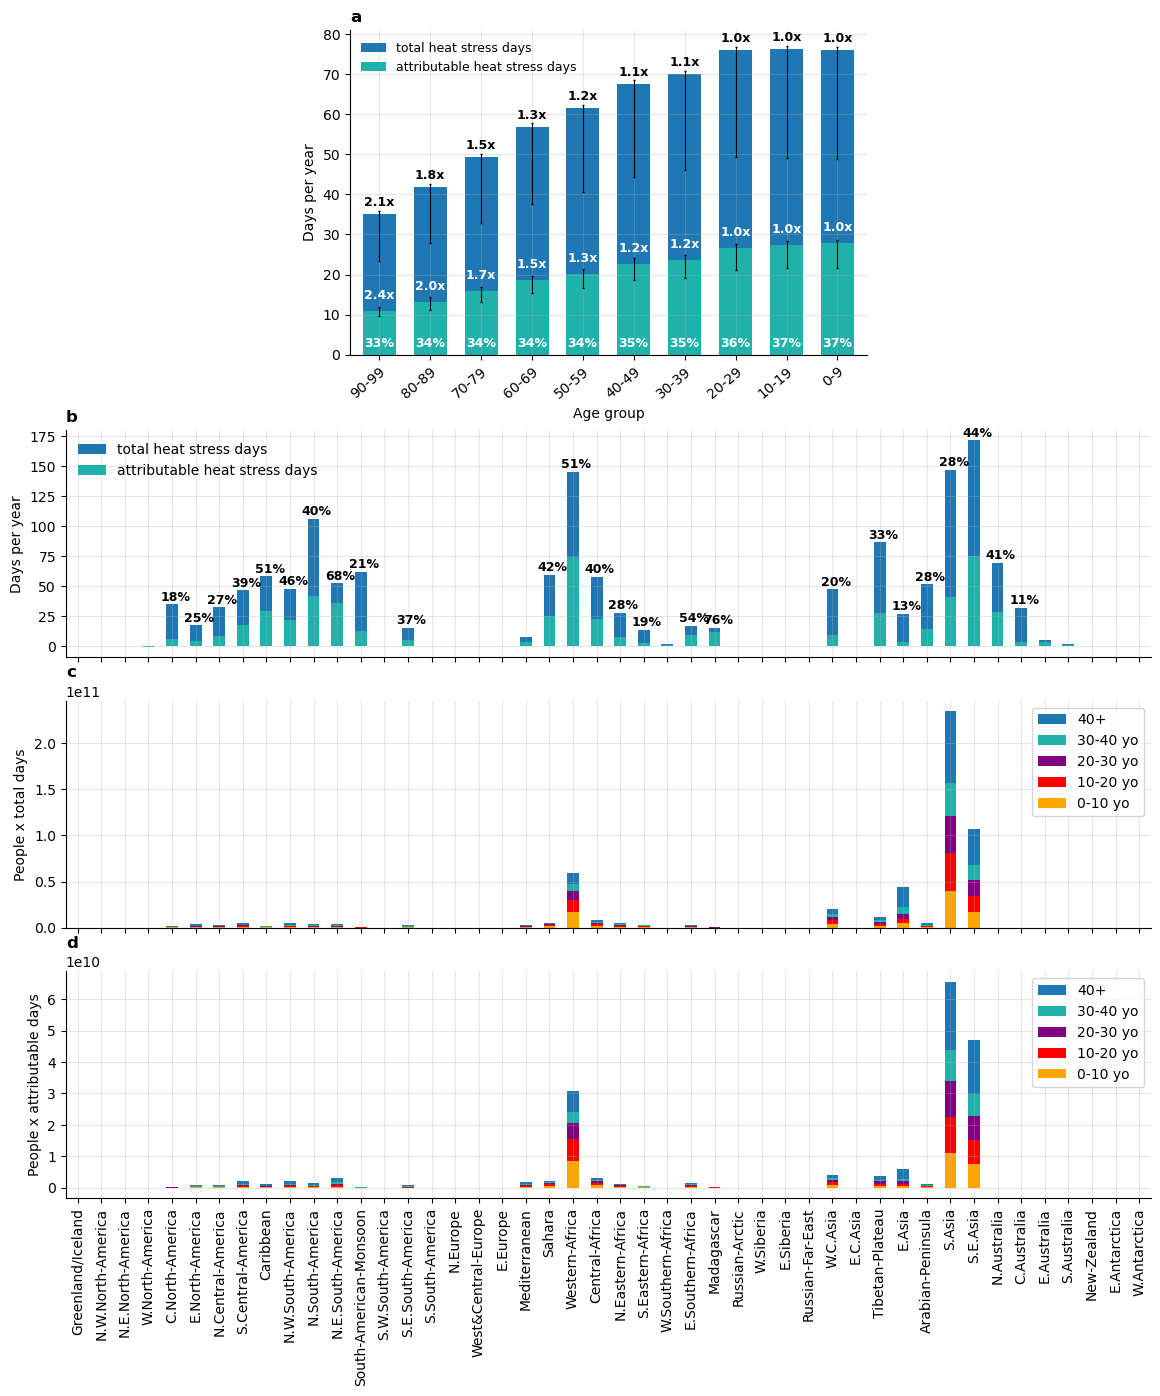

In [141]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Figure 
fig = plt.figure(figsize=(14,16))

gs = GridSpec(
    nrows=4,
    ncols=3,
    figure=fig,
    width_ratios=[.4,1,.4],
    height_ratios=[1,.7,.7,.7],
    hspace=0.3,
    wspace=0.25,
)

# Top centered map (spans both columns)
ax1 = fig.add_subplot(gs[0, 1])

ax2 = fig.add_subplot(gs[1,:])
ax3= fig.add_subplot(gs[2,:],sharex=ax2)
ax4= fig.add_subplot(gs[3,:],sharex=ax3)

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + 0.02, pos.width, pos.height])

pos = ax4.get_position()
ax4.set_position([pos.x0, pos.y0 + 0.04, pos.width, pos.height])

# a
ax=ax1
plot_barplot_n_prop_people_atleastx_median(da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days'), 
                                                  unit=1, 
                                                  ax=ax, 
                                                  proportion=False, 
                                                  x_hot_days = None,
                                                 legend=False,
                                                 errcolor='k',
                                                 color='C0',
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel='Number of days per year',
                                                 alpha_scale=False,
                                                 width=.65,
                                                 leg_title=None)

plot_barplot_n_prop_people_atleastx_median(da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days'), 
                                                  unit=1, 
                                                  ax=ax, 
                                                  proportion=False, 
                                                  x_hot_days = None,
                                                 legend=False,
                                                 errcolor='k',
                                                 color='lightseagreen',
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel='Days per year',
                                                 alpha_scale=False,
                                                 width=.65,
                                                 leg_title=None)


# annotate with multiplication factors

# total days 
df = da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
for i in range(10):
    val = df.agg(['median'],axis=1).iloc[i].values
    EMF = (df.iloc[0,:] / df).agg(['median'],axis=1).round(1).iloc[i].values[0]
    ax.annotate(f'{EMF}x', (i+.3, val+2), fontweight='bold', c='k', fontsize=9)

# attr days 
df = da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
for i in range(10):
    val = df.agg(['median'],axis=1).iloc[i].values
    EMF = (df.iloc[0,:] / df).agg(['median'],axis=1).round(1).iloc[i].values[0]
    ax.annotate(f'{EMF}x', (i+.3, val+3), fontweight='bold',  c='white', fontsize=9 )


# what % of the total is attributable per age group, write underneath 
df1 = da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
df2 = da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
for i in range(10):
    percent = (df2/df1).agg(['median'],axis=1).round(2).iloc[i].values[0]
    ax.annotate(f'{int(percent*100)}%', (i+.3, 2), fontweight='bold',  c='white', fontsize=9 )

# labels

ax.legend(labels = ['total heat stress days', 'attributable heat stress days'], frameon=False, fontsize=9)
ax.set_xlabel('Age group')
ax.invert_xaxis()
ax.set_title('a', fontweight='bold', loc='left')



# # b
ax=ax2

totdays_per_person.median('dataset').squeeze().to_pandas().T.plot(kind="bar", ax=ax, label='total heat stress days')
nAHD_per_person.median('dataset').squeeze().to_pandas().T.plot(kind="bar", ax=ax, color='lightseagreen', label='attributable heat stress days')


# annotate
for i in range(46):
    tot = totdays_per_person.median('dataset').squeeze().to_pandas().T.iloc[i]
    percent = (nAHD_per_person.median('dataset').squeeze().to_pandas().T / totdays_per_person.median('dataset').squeeze().to_pandas().T).round(2).iloc[i] * 100
    if tot > 10 :
        ax.annotate(f'{int(percent)}%', (i-.5, tot+3), fontweight='bold',  c='k', fontsize=9 )

ax.set_ylabel('Days per year')
ax.set_xlabel('')
ax.legend(frameon=False)
ax.set_title('b', fontweight='bold', loc='left')



# # c
ax=ax3

pop_x_daystot_ar6_sum.median('dataset').squeeze().rename({"mask": "region"}).assign_coords(
    region=("region", ar6.names)
).to_pandas().plot(kind="bar",ax=ax, label='40+')
(pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum + pop_x_diff_ar6_2030_sum + pop_x_diff_ar6_3040_sum).to_pandas().plot(kind="bar", ax=ax, color='lightseagreen', label='30-40 yo')
(pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum + pop_x_diff_ar6_2030_sum).to_pandas().plot(kind="bar", ax=ax, color='purple', label='20-30 yo')
(pop_x_diff_ar6_010_sum + pop_x_diff_ar6_1020_sum).to_pandas().plot(kind="bar", ax=ax, color='red', label='10-20 yo')
pop_x_diff_ar6_010_sum.to_pandas().plot(kind="bar", ax=ax, color='orange', label='0-10 yo')


ax.set_ylabel('People x total days')
ax.set_xlabel('')
ax.legend()
ax.set_title('c', fontweight='bold', loc='left')

# # d 
ax=ax4
series_40plus = pop_x_nAHD_ar6_sum.median('dataset').squeeze().rename({"mask": "region"}).assign_coords(
    region=("region", ar6.names)
).to_pandas()


series_40plus.plot(kind="bar",ax=ax, label='40+',color='C0')
(pop_x_diff_ar6_010_sum2 + pop_x_diff_ar6_1020_sum2 + pop_x_diff_ar6_2030_sum2 + pop_x_diff_ar6_3040_sum2).to_pandas().plot(kind="bar", ax=ax, color='lightseagreen', label='30-40 yo')
(pop_x_diff_ar6_010_sum2 + pop_x_diff_ar6_1020_sum2 + pop_x_diff_ar6_2030_sum2).to_pandas().plot(kind="bar", ax=ax, color='purple', label='20-30 yo')
(pop_x_diff_ar6_010_sum2 + pop_x_diff_ar6_1020_sum2).to_pandas().plot(kind="bar", ax=ax, color='red', label='10-20 yo')
pop_x_diff_ar6_010_sum2.to_pandas().plot(kind="bar", ax=ax, color='orange', label='0-10 yo')

ax.set_ylabel('People x attributable days')
ax.set_xlabel('')
ax.legend()
ax.set_title('d', fontweight='bold', loc='left')


for ax in [ax1,ax2,ax3,ax4]:
    ax.grid(alpha=.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_total_attributable_people_x_days_perregion_subplots.png'),bbox_inches='tight',dpi=300)

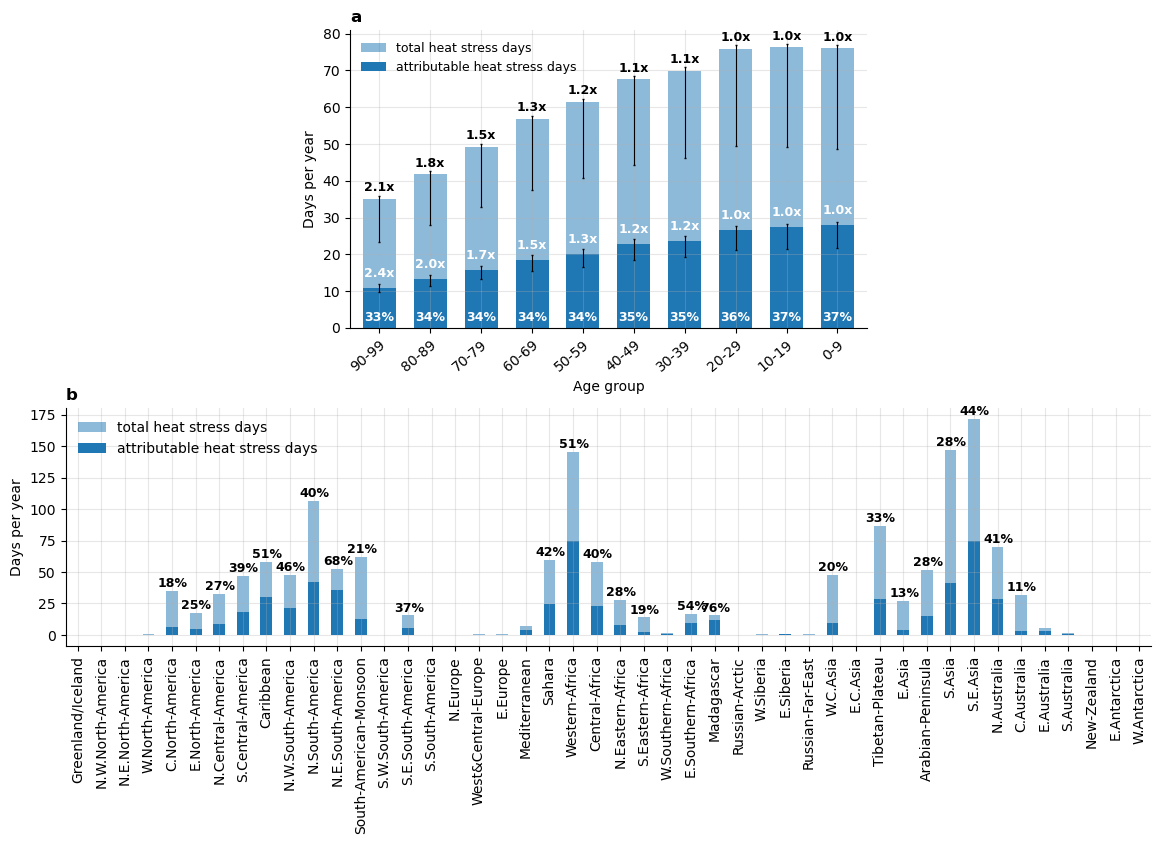

In [142]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Figure 
fig = plt.figure(figsize=(14,8))

gs = GridSpec(
    nrows=2,
    ncols=3,
    figure=fig,
    width_ratios=[.4,1,.4],
    height_ratios=[1,.8],
    hspace=0.3,
    wspace=0.25,
)

# Top centered map (spans both columns)
ax1 = fig.add_subplot(gs[0, 1])

ax2 = fig.add_subplot(gs[1,:])

# a
ax=ax1
plot_barplot_n_prop_people_atleastx_median(da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days'), 
                                                  unit=1, 
                                                  ax=ax, 
                                                  proportion=False, 
                                                  x_hot_days = None,
                                                 legend=False,
                                                 errcolor='k',
                                                 color='C0',
                                                 alpha=.5,
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel='Number of days per year',
                                                 alpha_scale=False,
                                                 width=.65,
                                                 leg_title=None)

plot_barplot_n_prop_people_atleastx_median(da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days'), 
                                                  unit=1, 
                                                  ax=ax, 
                                                  proportion=False, 
                                                  x_hot_days = None,
                                                 legend=False,
                                                 errcolor='k',
                                                 color='C0',
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel='Days per year',
                                                 alpha_scale=False,
                                                 width=.65,
                                                 leg_title=None)


# annotate with multiplication factors

# total days 
df = da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
for i in range(10):
    val = df.agg(['median'],axis=1).iloc[i].values
    EMF = (df.iloc[0,:] / df).agg(['median'],axis=1).round(1).iloc[i].values[0]
    ax.annotate(f'{EMF}x', (i+.3, val+2), fontweight='bold', c='k', fontsize=9)

# attr days 
df = da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
for i in range(10):
    val = df.agg(['median'],axis=1).iloc[i].values
    EMF = (df.iloc[0,:] / df).agg(['median'],axis=1).round(1).iloc[i].values[0]
    ax.annotate(f'{EMF}x', (i+.3, val+3), fontweight='bold',  c='white', fontsize=9 )


# what % of the total is attributable per age group, write underneath 
df1 = da_totaldays_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
df2 = da_nAHD_percapita_peopledays_10y_obs.sel(features= 'per_capita_days').to_pandas().T
for i in range(10):
    percent = (df2/df1).agg(['median'],axis=1).round(2).iloc[i].values[0]
    ax.annotate(f'{int(percent*100)}%', (i+.3, 2), fontweight='bold',  c='white', fontsize=9 )

# labels

ax.legend(labels = ['total heat stress days', 'attributable heat stress days'], frameon=False, fontsize=9)
ax.set_xlabel('Age group')
ax.invert_xaxis()
ax.set_title('a', fontweight='bold', loc='left')



# # b
ax=ax2

totdays_per_person.median('dataset').squeeze().to_pandas().T.plot(
    kind="bar", 
    ax=ax,
    color='C0',
    alpha= .5 , 
    label='total heat stress days',
    )
nAHD_per_person.median('dataset').squeeze().to_pandas().T.plot(
    kind="bar", 
    ax=ax, 
    color='C0',
    label='attributable heat stress days',
)


# annotate
for i in range(46):
    tot = totdays_per_person.median('dataset').squeeze().to_pandas().T.iloc[i]
    percent = (nAHD_per_person.median('dataset').squeeze().to_pandas().T / totdays_per_person.median('dataset').squeeze().to_pandas().T).round(2).iloc[i] * 100
    if tot > 10 :
        ax.annotate(f'{int(percent)}%', (i-.6, tot+3), fontweight='bold',  c='k', fontsize=9 )

ax.set_ylabel('Days per year')
ax.set_xlabel('')
ax.legend(frameon=False)
ax.set_title('b', fontweight='bold', loc='left')



for ax in [ax1,ax2,ax3,ax4]:
    ax.grid(alpha=.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_total_attributable_people_x_days_perregion_subplots_onlyab.png'),bbox_inches='tight',dpi=300)

## summary results per AR6 region (Comms)

In [25]:
pd.DataFrame({
    "number": ar6.numbers,
    "abbrev": ar6.abbrevs,
    "name": ar6.names
})

,number,abbrev,name
0,0,GIC,Greenland/Iceland
1,1,NWN,N.W.North-America
2,2,NEN,N.E.North-America
3,3,WNA,W.North-America
4,4,CNA,C.North-America
5,5,ENA,E.North-America
6,6,NCA,N.Central-America
7,7,SCA,S.Central-America
8,8,CAR,Caribbean
9,9,NWS,N.W.South-America


In [32]:
region_id = ar6.map_keys("SAS") # South Asia

gs_population_region = gs_population_global.where(mask == region_id)

da_n_people_ar6, da_prop_people_ar6 = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    datasets,
    da_nAHD,
    x_hot_days=[1, 5, 10, 20, 30, 50, 100, 150]
)

da_n_people_ar6_models, da_prop_people_ar6_models = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    GCMs,
    da_nAHD_models,
    x_hot_days=[1, 5, 10, 20, 30, 50, 100, 150]
)



In [38]:
da_n_people_ar6_p0, _ = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    datasets,
    da_p0_obs.rename({'dataset':'model'}),
    x_hot_days=[1, 5, 10, 20, 30, 50, 100,150]
)

da_n_people_ar6_p1, _ = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    datasets,
    da_p1_obs.rename({'dataset':'model'}),
    x_hot_days=[1, 5, 10, 20, 30, 50,100,150]
)

da_n_people_ar6_p0_models, _ = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    GCMs,
    da_p0_models_emp*365.25,
    x_hot_days=[1, 5, 10, 20, 30, 50,100,150]
)

da_n_people_ar6_p1_models, da_prop_people_ar6_p1_models = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    GCMs,
    da_p1_models_emp*365.25,
    x_hot_days=[1, 5, 10, 20, 30, 50,100,150]
)

In [33]:
# attributable days - reanalysis

(da_n_people_ar6.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float).round(-1)

features
n_atleast_1      260.0
n_atleast_5      260.0
n_atleast_10     260.0
n_atleast_20     230.0
n_atleast_30     170.0
n_atleast_50      80.0
n_atleast_100      0.0
n_atleast_150      0.0
dtype: float64

In [35]:
(da_n_people_ar6_models.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float).round(-1)

# GCMs attributable days

features
n_atleast_1      270.0
n_atleast_5      260.0
n_atleast_10     260.0
n_atleast_20     230.0
n_atleast_30     170.0
n_atleast_50      80.0
n_atleast_100     10.0
n_atleast_150      0.0
dtype: float64

In [36]:
(da_prop_people_ar6_models.sel(age_ranges=0).to_pandas().median(axis=0)).astype(float).round(2)

# GCMs atrributable days

features
prop_atleast_1      0.99
prop_atleast_5      0.98
prop_atleast_10     0.98
prop_atleast_20     0.85
prop_atleast_30     0.62
prop_atleast_50     0.31
prop_atleast_100    0.02
prop_atleast_150    0.00
dtype: float64

In [192]:
#total days - reanalysis

df0=(da_n_people_ar6_p0.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)
df1 = (da_n_people_ar6_p1.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)

(df1/df0).round(1)


features
n_atleast_1      1.0
n_atleast_5      1.0
n_atleast_10     1.0
n_atleast_20     1.0
n_atleast_30     1.1
n_atleast_50     1.2
n_atleast_100    1.4
n_atleast_150    3.0
dtype: float64

In [ ]:
df0_mod=(da_n_people_ar6_p0_models.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)
df1_mod = (da_n_people_ar6_p1_models.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)

(df1_mod/df0_mod).round(1)

# doubled the number of children living through xx total heat stress

features
n_atleast_1      1.0
n_atleast_5      1.0
n_atleast_10     1.0
n_atleast_20     1.0
n_atleast_30     1.1
n_atleast_50     1.2
n_atleast_100    1.3
n_atleast_150    2.1
dtype: float64

In [194]:
df0

features
n_atleast_1      264.567132
n_atleast_5      262.032902
n_atleast_10     256.514688
n_atleast_20     251.619336
n_atleast_30     244.967438
n_atleast_50     215.144574
n_atleast_100    154.022312
n_atleast_150     51.309865
dtype: float64

In [ ]:
df1

# number of children

features
n_atleast_1      265.130611
n_atleast_5      264.501623
n_atleast_10     263.723535
n_atleast_20     262.505994
n_atleast_30     259.880881
n_atleast_50     251.771044
n_atleast_100    217.831321
n_atleast_150    154.791617
dtype: float64

In [39]:
(da_prop_people_ar6_p1_models.sel(age_ranges=0).to_pandas().median(axis=0)).astype(float)

features
prop_atleast_1      0.987353
prop_atleast_5      0.984681
prop_atleast_10     0.982172
prop_atleast_20     0.977712
prop_atleast_30     0.971931
prop_atleast_50     0.944943
prop_atleast_100    0.795152
prop_atleast_150    0.582792
dtype: float64

In [196]:
df0_mod

features
n_atleast_1      263.417456
n_atleast_5      260.933259
n_atleast_10     257.927216
n_atleast_20     252.614187
n_atleast_30     247.062275
n_atleast_50     218.032931
n_atleast_100    162.242567
n_atleast_150     75.376388
dtype: float64

In [ ]:
df1_mod.round(-1)

features
n_atleast_1      265.247740
n_atleast_5      264.529873
n_atleast_10     263.855870
n_atleast_20     262.657764
n_atleast_30     261.104828
n_atleast_50     253.854582
n_atleast_100    213.613733
n_atleast_150    156.564283
dtype: float64

In [40]:
region_id = ar6.map_keys("SEA")

gs_population_region = gs_population_global.where(mask == region_id)

da_n_people_ar6, da_prop_people_ar6 = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    datasets,
    da_nAHD,
    x_hot_days=[1, 5, 10, 20, 30, 50]
)

da_n_people_ar6_models, da_prop_people_ar6_models = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    GCMs,
    da_nAHD_models,
    x_hot_days=[1, 5, 10, 20, 30, 50]
)



In [41]:
da_n_people_ar6_p0, _ = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    datasets,
    da_p0_obs.rename({'dataset':'model'}),
    x_hot_days=[1, 5, 10, 20, 30, 50, 100,150]
)

da_n_people_ar6_p1, _ = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    datasets,
    da_p1_obs.rename({'dataset':'model'}),
    x_hot_days=[1, 5, 10, 20, 30, 50,100,150]
)

da_n_people_ar6_p0_models, _ = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    GCMs,
    da_p0_models_emp*365.25,
    x_hot_days=[1, 5, 10, 20, 30, 50,100,150]
)

da_n_people_ar6_p1_models, da_prop_people_ar6_p1_models = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    GCMs,
    da_p1_models_emp*365.25,
    x_hot_days=[1, 5, 10, 20, 30, 50,100,150]
)

In [200]:
# attributable days - reanalysis

(da_n_people_ar6.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float).round(-1)

features
n_atleast_1     100.0
n_atleast_5     100.0
n_atleast_10    100.0
n_atleast_20     90.0
n_atleast_30     70.0
n_atleast_50     50.0
dtype: float64

In [ ]:
(da_n_people_ar6_models.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float).round(-1)

# GCMs - n people, attributable days

features
n_atleast_1     100.0
n_atleast_5     100.0
n_atleast_10    100.0
n_atleast_20     90.0
n_atleast_30     90.0
n_atleast_50     90.0
dtype: float64

In [ ]:
(da_prop_people_ar6_models.sel(age_ranges=0).to_pandas().median(axis=0)).astype(float).round(2)

# prop people exposed to n attr days


features
prop_atleast_1     0.96
prop_atleast_5     0.94
prop_atleast_10    0.94
prop_atleast_20    0.92
prop_atleast_30    0.90
prop_atleast_50    0.86
dtype: float64

In [202]:
#total days - reanalysis

df0=(da_n_people_ar6_p0.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)
df1 = (da_n_people_ar6_p1.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)

(df1/df0).round(1)


features
n_atleast_1      1.1
n_atleast_5      1.1
n_atleast_10     1.1
n_atleast_20     1.2
n_atleast_30     1.2
n_atleast_50     1.3
n_atleast_100    1.7
n_atleast_150    3.9
dtype: float64

In [ ]:
df0_mod=(da_n_people_ar6_p0_models.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)
df1_mod = (da_n_people_ar6_p1_models.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)

(df1_mod/df0_mod).round(1)

#total days - GCMs - nearly quadrupled


features
n_atleast_1      1.1
n_atleast_5      1.1
n_atleast_10     1.1
n_atleast_20     1.2
n_atleast_30     1.3
n_atleast_50     1.5
n_atleast_100    2.0
n_atleast_150    3.8
dtype: float64

In [208]:
df0.round(0)

features
n_atleast_1      93.0
n_atleast_5      89.0
n_atleast_10     86.0
n_atleast_20     80.0
n_atleast_30     75.0
n_atleast_50     68.0
n_atleast_100    44.0
n_atleast_150    16.0
dtype: float64

In [209]:
df1.round(0)

features
n_atleast_1      98.0
n_atleast_5      96.0
n_atleast_10     95.0
n_atleast_20     93.0
n_atleast_30     91.0
n_atleast_50     88.0
n_atleast_100    77.0
n_atleast_150    63.0
dtype: float64

In [210]:
df0_mod.round(0)

features
n_atleast_1      91.0
n_atleast_5      86.0
n_atleast_10     83.0
n_atleast_20     77.0
n_atleast_30     72.0
n_atleast_50     62.0
n_atleast_100    42.0
n_atleast_150    19.0
dtype: float64

In [211]:
df1_mod.round(0)

features
n_atleast_1      98.0
n_atleast_5      96.0
n_atleast_10     95.0
n_atleast_20     94.0
n_atleast_30     93.0
n_atleast_50     90.0
n_atleast_100    84.0
n_atleast_150    73.0
dtype: float64

In [46]:
da_prop_people_ar6_p1_models.sel(age_ranges=0).to_pandas().median(axis=0).astype(float).round(2)

features
prop_atleast_1      0.97
prop_atleast_5      0.94
prop_atleast_10     0.94
prop_atleast_20     0.92
prop_atleast_30     0.91
prop_atleast_50     0.89
prop_atleast_100    0.83
prop_atleast_150    0.72
dtype: float64

In [47]:
region_id = ar6.map_keys("WAF")

gs_population_region = gs_population_global.where(mask == region_id)

da_n_people_ar6, da_prop_people_ar6 = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    datasets,
    da_nAHD,
    x_hot_days=[1, 5, 10, 20, 30, 50]
)

da_n_people_ar6_models, da_prop_people_ar6_models = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    GCMs,
    da_nAHD_models,
    x_hot_days=[1, 5, 10, 20, 30, 50]
)



In [48]:
da_n_people_ar6_p0, _ = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    datasets,
    da_p0_obs.rename({'dataset':'model'}),
    x_hot_days=[1, 5, 10, 20, 30, 50, 100,150]
)

da_n_people_ar6_p1, _ = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    datasets,
    da_p1_obs.rename({'dataset':'model'}),
    x_hot_days=[1, 5, 10, 20, 30, 50,100,150]
)

da_n_people_ar6_p0_models, _ = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    GCMs,
    da_p0_models_emp*365.25,
    x_hot_days=[1, 5, 10, 20, 30, 50,100,150]
)

da_n_people_ar6_p1_models, da_prop_people_ar6_p1_models = calc_number_proportion_people_atleastxdays_10yr(
    gs_population_region,
    GCMs,
    da_p1_models_emp*365.25,
    x_hot_days=[1, 5, 10, 20, 30, 50,100,150]
)

In [214]:
# attributable days - reanalysis

(da_n_people_ar6.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float).round(-1)

features
n_atleast_1     120.0
n_atleast_5     120.0
n_atleast_10    120.0
n_atleast_20    120.0
n_atleast_30    100.0
n_atleast_50     70.0
dtype: float64

In [215]:
(da_n_people_ar6_models.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float).round(-1)

# GCMs

features
n_atleast_1     120.0
n_atleast_5     120.0
n_atleast_10    120.0
n_atleast_20    120.0
n_atleast_30    110.0
n_atleast_50    110.0
dtype: float64

In [51]:
(da_prop_people_ar6.sel(age_ranges=0).to_pandas().median(axis=0)).astype(float).round(2)


features
prop_atleast_1     0.98
prop_atleast_5     0.98
prop_atleast_10    0.97
prop_atleast_20    0.95
prop_atleast_30    0.92
prop_atleast_50    0.80
dtype: float64

In [50]:
(da_prop_people_ar6_models.sel(age_ranges=0).to_pandas().median(axis=0)).astype(float).round(2)


features
prop_atleast_1     0.98
prop_atleast_5     0.98
prop_atleast_10    0.98
prop_atleast_20    0.97
prop_atleast_30    0.96
prop_atleast_50    0.92
dtype: float64

In [54]:
#total days - reanalysis

df0=(da_n_people_ar6_p0.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)
df1 = (da_n_people_ar6_p1.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)

(df1/df0).round(1)


features
n_atleast_1       1.0
n_atleast_5       1.0
n_atleast_10      1.0
n_atleast_20      1.1
n_atleast_30      1.1
n_atleast_50      1.4
n_atleast_100     4.0
n_atleast_150    59.7
dtype: float64

In [55]:
df0_mod=(da_n_people_ar6_p0_models.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)
df1_mod = (da_n_people_ar6_p1_models.sel(age_ranges=0).to_pandas().median(axis=0) / 1e6).astype(float)

(df1_mod/df0_mod).round(1)

features
n_atleast_1      1.0
n_atleast_5      1.0
n_atleast_10     1.0
n_atleast_20     1.1
n_atleast_30     1.1
n_atleast_50     1.3
n_atleast_100    2.7
n_atleast_150    4.7
dtype: float64

In [56]:
df0.round()

features
n_atleast_1      116.0
n_atleast_5      115.0
n_atleast_10     114.0
n_atleast_20     109.0
n_atleast_30     104.0
n_atleast_50      80.0
n_atleast_100     24.0
n_atleast_150      1.0
dtype: float64

In [57]:
df1.round()

features
n_atleast_1      117.0
n_atleast_5      117.0
n_atleast_10     116.0
n_atleast_20     115.0
n_atleast_30     114.0
n_atleast_50     111.0
n_atleast_100     93.0
n_atleast_150     50.0
dtype: float64

In [58]:
df0_mod.round()

features
n_atleast_1      115.0
n_atleast_5      114.0
n_atleast_10     113.0
n_atleast_20     108.0
n_atleast_30     103.0
n_atleast_50      89.0
n_atleast_100     37.0
n_atleast_150     14.0
dtype: float64

In [59]:
df1_mod.round()

features
n_atleast_1      117.0
n_atleast_5      117.0
n_atleast_10     116.0
n_atleast_20     115.0
n_atleast_30     115.0
n_atleast_50     113.0
n_atleast_100    101.0
n_atleast_150     65.0
dtype: float64

In [61]:
da_prop_people_ar6_p1_models.sel(age_ranges=0).to_pandas().median(axis=0).astype(float).round(2)

features
prop_atleast_1      0.98
prop_atleast_5      0.98
prop_atleast_10     0.98
prop_atleast_20     0.97
prop_atleast_30     0.96
prop_atleast_50     0.95
prop_atleast_100    0.85
prop_atleast_150    0.55
dtype: float64